# Sprint (2)

## Voorspellen van Wedstrijdresultaten in Europees Voetbal

**Vak:** Datalab 2  
**Klas:** ADS & AI Zm 1a  
**Groep:** 3  
**Het gekozen Team:** ADO Den Haag  


## Content :

[1. Doel van het project](#1-doel-van-het-project)

[2. Database laden](#2-database-laden)

[2.1 Importing Libraries](#2.1-importing-libraries)

[2.2 Data inladen uit de SQL database](#22-data-inladen-uit-de-sql-database)

[2.3 Tabellen laden uit de database](#23-tabellen-laden-uit-de-database)

[2.4 Kolombeschrijvinge](#2.4-kolombeschrijving)

[3. Identifiers](#3-identifiers)

[4. Ranglijst](#4-ranglijst)



## 1. Doel van het project

Het doel van dit project is om een voorspellend model te ontwikkelen dat het resultaat van een voetbalwedstrijd kan voorspellen:
- Winst
- Gelijkspel
- Verlies

Hiervoor gebruiken we data uit de **European Soccer Database**.

Op basis van de variabelen met de meeste voorspellende waarde formuleren we een advies voor de technisch directeur van de club. De centrale vragen zijn:

> Minder miskopen bij transfers

> Voorspellen welke spelers goed bij het team passen

> Begrijpen welke speelstijl het meeste succes geeft

> Wedstrijdresultaten beter voorspellen

Dataset bron:  
https://www.kaggle.com/datasets/hugomathien/soccer

## 2. Database laden

### 2.1 Libraries importeren

In [92]:
# Libraries importeren
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

### 2.2 Data inladen uit de SQL database

In [93]:
# Data inladen uit de SQL database
conn = sqlite3.connect("database.sqlite")
tables = pd.read_sql("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""", conn)

tables

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


### 2.3 Tabellen laden uit de database

In [94]:
def load_tables(conn):
    """
    Laadt alle belangrijke tabellen uit de SQLite database.

    Parameters:
    conn: database connectie

    Returns:
    dict: dictionary met alle dataframes
    """
    tables = {
        "Player_Attributes": pd.read_sql("SELECT * FROM Player_Attributes;", conn),
        "Player": pd.read_sql("SELECT * FROM Player;", conn),
        "Match": pd.read_sql("SELECT * FROM Match;", conn),
        "League": pd.read_sql("SELECT * FROM League;", conn),
        "Country": pd.read_sql("SELECT * FROM Country;", conn),
        "Team": pd.read_sql("SELECT * FROM Team;", conn),
        "Team_Attributes": pd.read_sql("SELECT * FROM Team_Attributes;", conn)
    }
    
    return tables

In [95]:
# Tabellen inladen uit de database

tables = load_tables(conn)

Player_Attributes_df = tables["Player_Attributes"]
Player_df = tables["Player"]
Match_df = tables["Match"]
League_df = tables["League"]
Country_df = tables["Country"]
Team_df = tables["Team"]
Team_Attributes_df = tables["Team_Attributes"]

display(Team_df.head())

,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673.0,KRC Genk,GEN
1,2,9993,675.0,Beerschot AC,BAC
2,3,10000,15005.0,SV Zulte-Waregem,ZUL
3,4,9994,2007.0,Sporting Lokeren,LOK
4,5,9984,1750.0,KSV Cercle Brugge,CEB


### 2.4 Kolombeschrijving

#### Beschrijving van kolommen in `Team`

| Kolom | Beschrijving | Datatype | Relaties |
| :--- | :--- | :--- | :---: |
| id | Unieke identificatie voor de rij | int | Geen directe relatie |
| team_api_id | Unieke API ID van het team | int | Gerelateerd aan team_api_id in `Team_Attributes` tabel |
| team_fifa_api_id | FIFA API ID van het team | int | Geen directe relatie |
| team_long_name | De volledige officiële naam van het team | str | Geen directe relatie |
| team_short_name | De afgekorte naam van het team | str | Geen directe relatie |

#### Beschrijving van kolommen in `Team_Attributes`

| Kolom | Beschrijving | Datatype | Relaties |
| :--- | :--- | :--- | :---: |
| id | Unieke identificatie voor de rij | int | Geen directe relatie |
| team_fifa_api_id | API ID van het team in de FIFA-database | int | Geen directe relatie |
| team_api_id | API ID van het team in deze database | int | Gerelateerd aan team_api_id in `Team` tabel |
| date | Datum van de attribuut-meting | DateTime | Geen directe relatie |
| buildUpPlaySpeed | Snelheid van de spelopbouw (waarde) | int | Geen directe relatie |
| buildUpPlaySpeedClass | Snelheidscategorie (bv. Fast, Balanced) | str | Geen directe relatie |
| buildUpPlayDribbling | Dribbelen tijdens spelopbouw (waarde) | int | Geen directe relatie |
| buildUpPlayDribblingClass | Dribbelcategorie (bv. Little, Normal) | str | Geen directe relatie |
| buildUpPlayPassing | Passing tijdens spelopbouw (waarde) | int | Geen directe relatie |
| buildUpPlayPassingClass | Passingcategorie (bv. Long, Short) | str | Geen directe relatie |
| buildUpPlayPositioningClass | Positionering (Organised/Free Form) | str | Geen directe relatie |
| chanceCreationPassing | Passing bij kansen creëren (waarde) | int | Geen directe relatie |
| chanceCreationPassingClass | Categorie voor passing bij kansen | str | Geen directe relatie |
| chanceCreationCrossing | Crossing bij kansen creëren (waarde) | int | Geen directe relatie |
| chanceCreationCrossingClass | Categorie voor crossing bij kansen | str | Geen directe relatie |
| chanceCreationShooting | Schieten bij kansen creëren (waarde) | int | Geen directe relatie |
| chanceCreationShootingClass | Categorie voor schieten bij kansen | str | Geen directe relatie |
| chanceCreationPositioningClass | Positionering bij kansen | str | Geen directe relatie |
| defencePressure | Druk zetten bij verdediging (waarde) | int | Geen directe relatie |
| defencePressureClass | Categorie voor druk zetten | str | Geen directe relatie |
| defenceAggression | Agressie bij verdediging (waarde) | int | Geen directe relatie |
| defenceAggressionClass | Categorie voor defensieve agressie | str | Geen directe relatie |
| defenceTeamWidth | Breedte van het team bij verdedigen | int | Geen directe relatie |
| defenceTeamWidthClass | Categorie voor defensieve breedte | str | Geen directe relatie |
| defenceDefenderLineClass | Type verdedigingslinie | str | Geen directe relatie |


#### Beschrijving van kolommen in `Player_Attributes`

| Kolom | Beschrijving | Datatype | Relaties |
|------|------|------|------|
| id | Unieke identifier van deze meting | int | Geen directe relatie |
| player_fifa_api_id | Unieke speler-ID vanuit FIFA (EA Sports) | int | Verwijst naar `Player.player_fifa_api_id` |
| player_api_id | Unieke speler-ID binnen de dataset | int | Verwijst naar `Player.player_api_id` |
| date | Datum waarop de attributen zijn vastgelegd | date | Geen directe relatie |
| overall_rating | Algemene vaardigheidsscore van de speler (0-99) | int | Geen directe relatie |
| potential | Maximale verwachte toekomstige score (0-99) | int | Geen directe relatie |
| preferred_foot | Voorkeursvoet (links of rechts) | str | Geen directe relatie |
| attacking_work_rate | Mate waarin speler aanvallend meewerkt | str | Geen directe relatie |
| defensive_work_rate | Mate waarin speler verdedigend meewerkt | str | Geen directe relatie |
| crossing | Kwaliteit van voorzetten (0-99) | int | Geen directe relatie |
| finishing | Afwerking van kansen (0-99) | int | Geen directe relatie |
| heading_accuracy | Nauwkeurigheid van kopballen (0-99) | int | Geen directe relatie |
| short_passing | Nauwkeurigheid van korte passes (0-99) | int | Geen directe relatie |
| volleys | Vaardigheid in schoten uit de lucht (0-99) | int | Geen directe relatie |
| dribbling | Vermogen om tegenstanders te passeren met de bal (0-99) | int | Geen directe relatie |
| curve | Vermogen om effect aan de bal te geven (0-99) | int | Geen directe relatie |
| free_kick_accuracy | Nauwkeurigheid van vrije trappen (0-99) | int | Geen directe relatie |
| long_passing | Nauwkeurigheid van lange passes (0-99) | int | Geen directe relatie |
| ball_control | Controle over de bal bij aannemen en dribbelen (0-99) | int | Geen directe relatie |
| acceleration | Snelheid waarmee speler op gang komt (0-99) | int | Geen directe relatie |
| sprint_speed | Maximale loopsnelheid (0-99) | int | Geen directe relatie |
| agility | Wendbaarheid en draaivermogen (0-99) | int | Geen directe relatie |
| reactions | Reactiesnelheid op situaties (0-99) | int | Geen directe relatie |
| balance | Stabiliteit en evenwicht (0-99) | int | Geen directe relatie |
| shot_power | Kracht van schoten (0-99) | int | Geen directe relatie |
| jumping | Sprongkracht (0-99) | int | Geen directe relatie |
| stamina | Uithoudingsvermogen (0-99) | int | Geen directe relatie |
| strength | Fysieke kracht (0-99) | int | Geen directe relatie |
| long_shots | Kwaliteit van afstandsschoten (0-99) | int | Geen directe relatie |
| aggression | Mate van felheid in duels (0-99) | int | Geen directe relatie |
| interceptions | Vermogen om passes te onderscheppen (0-99) | int | Geen directe relatie |
| positioning | Positionering zonder bal (0-99) | int | Geen directe relatie |
| vision | Inzicht in spel en passing opties (0-99) | int | Geen directe relatie |
| penalties | Nauwkeurigheid bij strafschoppen (0-99) | int | Geen directe relatie |
| marking | Verdedigend dekken van tegenstanders (0-99) | int | Geen directe relatie |
| standing_tackle | Tackles staand uitvoeren (0-99) | int | Geen directe relatie |
| sliding_tackle | Tackles glijdend uitvoeren (0-99) | int | Geen directe relatie |
| gk_diving | Duikvermogen van keeper (0-99) | int | Geen directe relatie |
| gk_handling | Balcontrole van keeper bij vangen (0-99) | int | Geen directe relatie |
| gk_kicking | Uittrappen en passen van keeper (0-99) | int | Geen directe relatie |
| gk_positioning | Positionering van keeper (0-99) | int | Geen directe relatie |
| gk_reflexes | Reactievermogen van keeper (0-99) | int | Geen directe relatie |


#### Beschrijving van kolommen in `match_df`

| Kolom | Beschrijving | Relaties |
|------|------|------|
| id | Unieke ID van de wedstrijd (rij in de tabel) | Geen directe relatie |
| country_id | ID van het land waar de competitie plaatsvindt | Verwijst naar `Country.id` |
| league_id | ID van de competitie | Verwijst naar `League.id` |
| season | Het seizoen waarin de wedstrijd is gespeeld | Geen directe relatie |
| stage | Speelronde binnen het seizoen | Geen directe relatie |
| date | Datum waarop de wedstrijd werd gespeeld | Geen directe relatie |
| match_api_id | Unieke ID van de wedstrijd uit het originele API systeem | Kan gebruikt worden in andere datasets |
| home_team_api_id | Unieke ID van het thuisteam | Verwijst naar `Team.team_api_id` |
| away_team_api_id | Unieke ID van het uitteam | Verwijst naar `Team.team_api_id` |
| home_team_goal | Aantal doelpunten van het thuisteam | Geen directe relatie |
| away_team_goal | Aantal doelpunten van het uitteam | Geen directe relatie |
| home_player_X1–X11 | X-positie van elke thuis speler op het veld | Gerelateerd aan spelers in `Player` tabel |
| away_player_X1–X11 | X-positie van elke uit speler op het veld | Gerelateerd aan spelers in `Player` tabel |
| home_player_Y1–Y11 | Y-positie van elke thuis speler op het veld | Gerelateerd aan spelers in `Player` tabel |
| away_player_Y1–Y11 | Y-positie van elke uit speler op het veld | Gerelateerd aan spelers in `Player` tabel |
| home_player_1–11 | Player IDs van de basisopstelling van het thuisteam | Verwijst naar `Player.player_api_id` |
| away_player_1–11 | Player IDs van de basisopstelling van het uitteam | Verwijst naar `Player.player_api_id` |
| goal | XML data met informatie over doelpunten | Geen directe relatie |
| shoton | XML data met schoten op doel | Geen directe relatie |
| shotoff | XML data met schoten naast doel | Geen directe relatie |
| foulcommit | XML data met overtredingen | Geen directe relatie |
| card | XML data met gele en rode kaarten | Geen directe relatie |
| cross | XML data met voorzetten | Geen directe relatie |
| corner | XML data met corners | Geen directe relatie |
| possession | XML data met balbezit | Geen directe relatie |


#### Bookmaker odds kolommen in `match_df`

| Kolom | Beschrijving | Bookmaker |
|------|------|------|
| B365H | Odds voor winst van het thuisteam | Bet365 |
| B365D | Odds voor een gelijkspel | Bet365 |
| B365A | Odds voor winst van het uitteam | Bet365 |
| BWH | Odds voor winst van het thuisteam | Bet&Win |
| BWD | Odds voor een gelijkspel | Bet&Win |
| BWA | Odds voor winst van het uitteam | Bet&Win |
| IWH | Odds voor winst van het thuisteam | Interwetten |
| IWD | Odds voor een gelijkspel | Interwetten |
| IWA | Odds voor winst van het uitteam | Interwetten |
| LBH | Odds voor winst van het thuisteam | Ladbrokes |
| LBD | Odds voor een gelijkspel | Ladbrokes |
| LBA | Odds voor winst van het uitteam | Ladbrokes |
| PSH | Odds voor winst van het thuisteam | Pinnacle Sports |
| PSD | Odds voor een gelijkspel | Pinnacle Sports |
| PSA | Odds voor winst van het uitteam | Pinnacle Sports |
| WHH | Odds voor winst van het thuisteam | William Hill |
| WHD | Odds voor een gelijkspel | William Hill |
| WHA | Odds voor winst van het uitteam | William Hill |
| SJH | Odds voor winst van het thuisteam | Stan James |
| SJD | Odds voor een gelijkspel | Stan James |
| SJA | Odds voor winst van het uitteam | Stan James |
| VCH | Odds voor winst van het thuisteam | VC Bet |
| VCD | Odds voor een gelijkspel | VC Bet |
| VCA | Odds voor winst van het uitteam | VC Bet |
| GBH | Odds voor winst van het thuisteam | Gamebookers |
| GBD | Odds voor een gelijkspel | Gamebookers |
| GBA | Odds voor winst van het uitteam | Gamebookers |
| BSH | Odds voor winst van het thuisteam | Blue Square |
| BSD | Odds voor een gelijkspel | Blue Square |
| BSA | Odds voor winst van het uitteam | Blue Square |

#### Kolommen in ``Player_df``

| Kolom               | Beschrijving                                                            | Datatype       | Relaties |
|---------------------|------------------------------------------------------------------------|----------------|-----------------------------|
| id                  | Unieke id voor elke speler                                             | int64          | Geen directe relatie                           |
| player_api_id       | Uniek nummer gebruikt door sportdata-API's                             | int64          | Wordt verwijst naar `Player_Attributes.player_api_id`                           |
| player_name         | Naam van de speler                                                     | object         | Geen directe relatie                           |
| player_fifa_api_id  | Uniek nummer gebruikt door FIFA                                        | int64          | Wordt verwijst naar `Player_Attributes.player_fifa_api_id`                           |
| birthday            | Verjaardag van de speler                                               | datetime64[ns] | Geen directe relatie                           |
| height              | Lengte van de speler                                                   | float64        | Geen directe relatie                           |
| weight              | Gewicht van de speler                                                  | float64        | Geen directe relatie                           |



#### Kolommen in ``League_df``

| Kolom       | Beschrijving                          | Datatype | Relaties                  |
|------------|--------------------------------------|----------|-----------------------------|
| id         | Unieke id voor elke competitie       | int64    | Wordt verwezen in `Match.league_id`        |
| country_id | Unieke id voor elk land              | int64    | Verwijst naar `Country_df.id` |
| name       | Naam van de competitie               | object   | Geen directe relatie        |



#### Kolommen in ``Country_df``

| Kolom | Beschrijving                     | Datatype | Relaties                   |
|------|----------------------------------|----------|-----------------------------|
| id   | Unieke id voor elk land         | int64    | Wordt verwijst naar `Match.country_id`    |
| name | Naam van het land               | object   | Geen directe relatie                      |

#### Bookmakers

In de bookmaker kolommen staan de letters **H**, **D** en **A**.  
Deze letters geven de mogelijke uitkomsten van een wedstrijd aan:

- **H (Home)** → het thuisteam wint  
- **D (Draw)** → de wedstrijd eindigt in een gelijkspel  
- **A (Away)** → het uitteam wint  

Voorbeeld:

- **B365H** → odds van Bet365 voor winst van het thuisteam  
- **B365D** → odds van Bet365 voor een gelijkspel  
- **B365A** → odds van Bet365 voor winst van het uitteam  


#### XML

**XML (eXtensible Markup Language)** is een manier om gestructureerde data als tekst op te slaan.

In deze dataset worden sommige wedstrijdgebeurtenissen opgeslagen als XML, bijvoorbeeld:

- doelpunten  
- schoten op doel  
- overtredingen  
- kaarten  

Hierdoor kan **veel informatie in één kolom worden opgeslagen**.

**Opmerking**

De kolommen `goal`, `shoton`, `shotoff`, `foulcommit`, `card`, `cross`, `corner` en `possession` bevatten XML data.  
Veel rijen hebben hier echter **geen of onvolledige data** (`None`). Daarom gaan we deze kolommen in deze analyse niet gebruikt.

### Waarom deze relaties belangrijk zijn

Deze relaties zijn nodig om de juiste data te selecteren en te analyseren.

- Via `league_id` kunnen we alleen wedstrijden uit de Eredivisie selecteren
- Via `team_api_id` kunnen we alle wedstrijden van ADO Den Haag vinden
- Via de team- en spelerinformatie kunnen we later kenmerken gebruiken voor het voorspellend model

Zonder deze relaties is het niet mogelijk om de juiste wedstrijden en teams te koppelen.

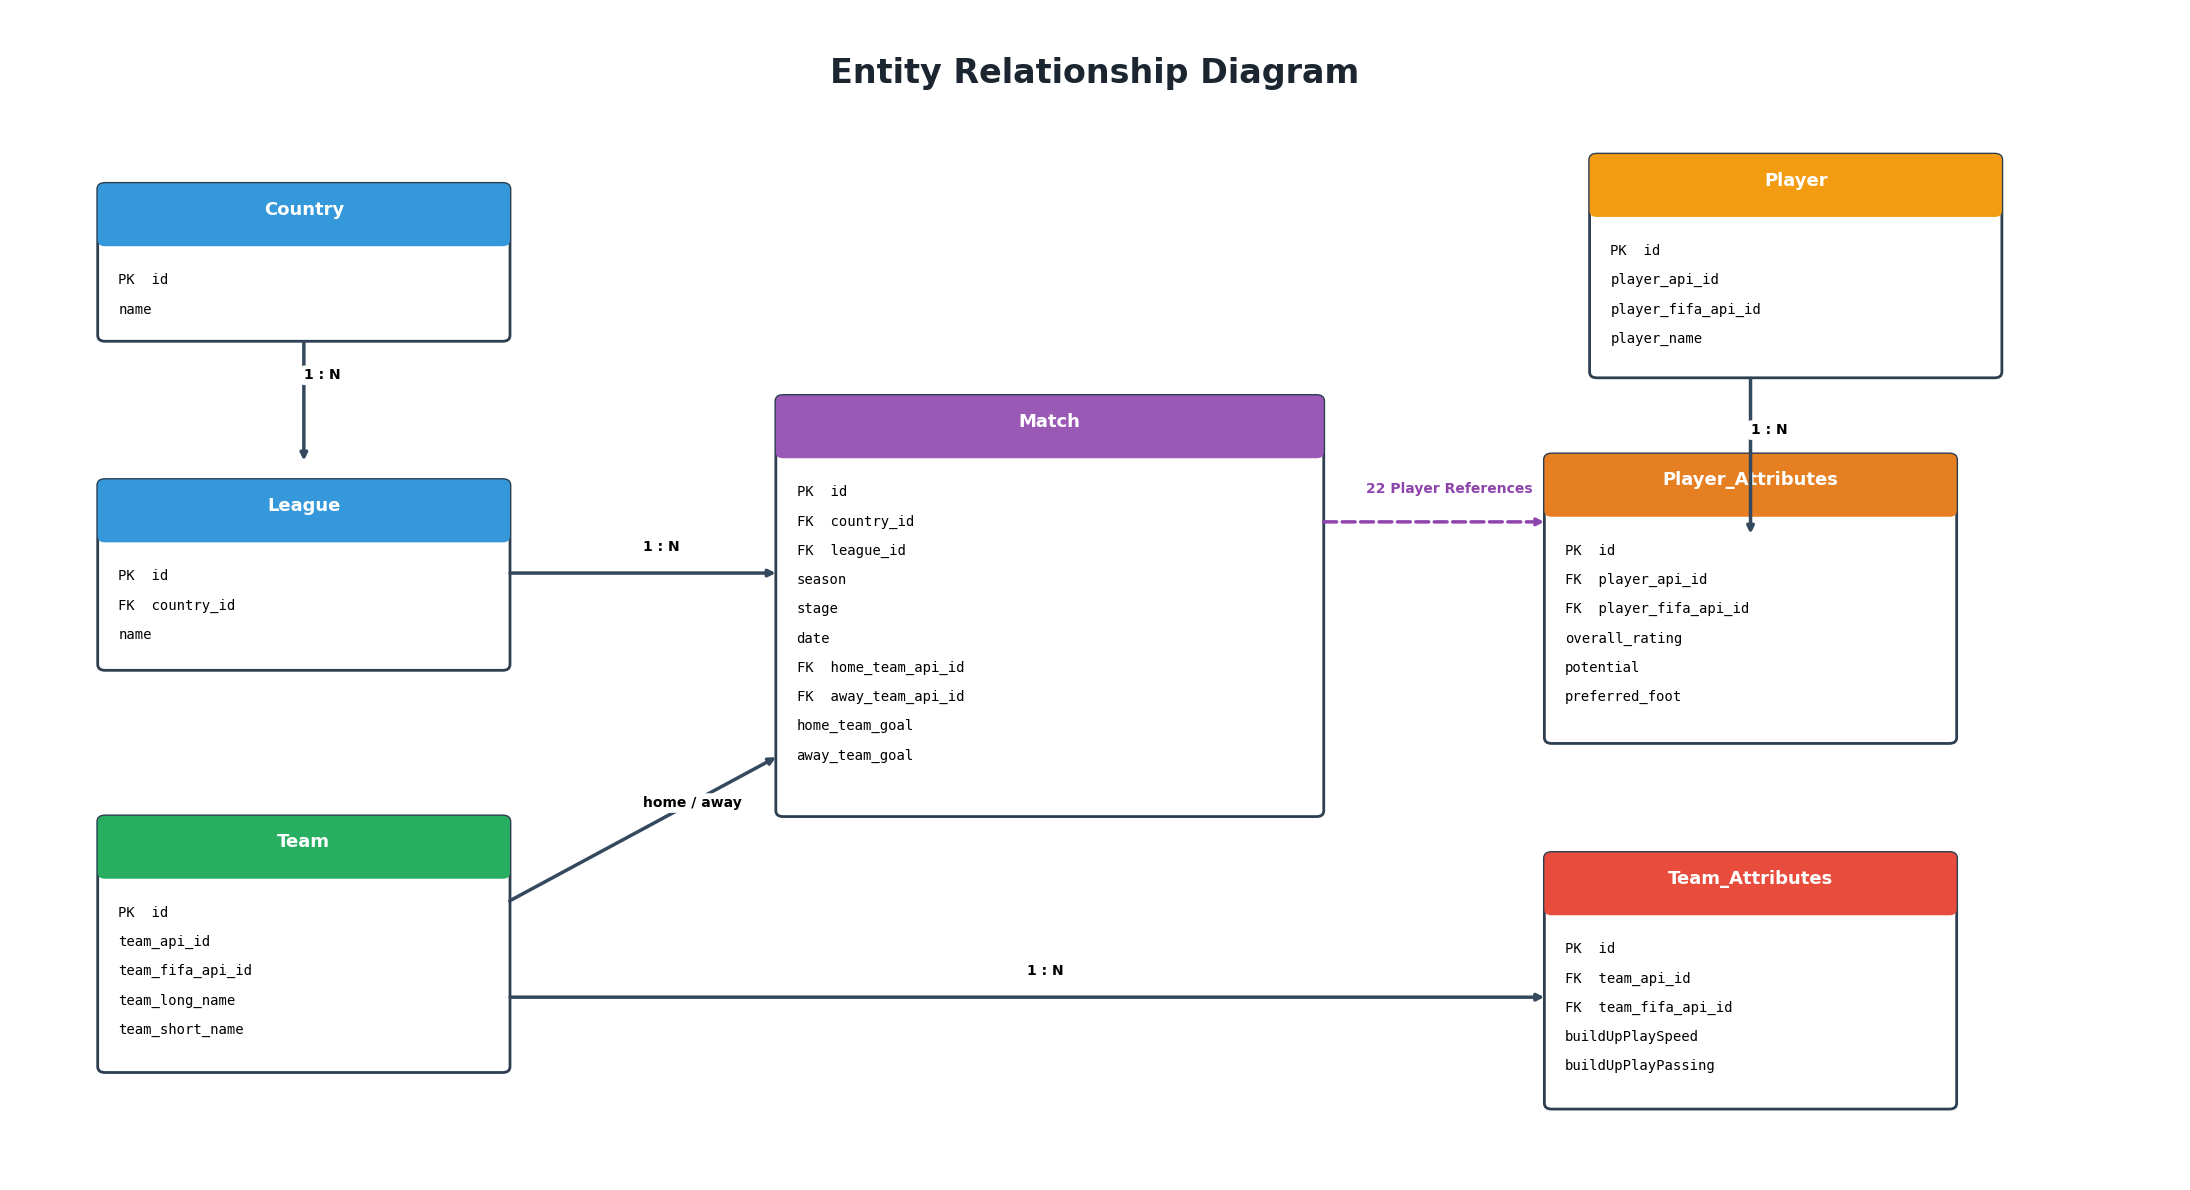

In [96]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ---------- FIGURE ----------
fig, ax = plt.subplots(figsize=(22, 12))
ax.set_xlim(0, 24)
ax.set_ylim(0, 16)
ax.axis('off')

# ---------- ENTITY FUNCTION ----------
def entity(x, y, title, fields, color, w=4.5):

    h = 0.45 * len(fields) + 1.2

    # main box
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=2,
        edgecolor="#2C3E50",
        facecolor="white"
    )

    ax.add_patch(box)

    # header
    header = FancyBboxPatch(
        (x, y + h - 0.8),
        w,
        0.8,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=0,
        facecolor=color
    )

    ax.add_patch(header)

    # title
    ax.text(
        x + w/2,
        y + h - 0.4,
        title,
        fontsize=13,
        fontweight='bold',
        ha='center',
        color='white'
    )

    # fields
    for i, f in enumerate(fields):
        ax.text(
            x + 0.2,
            y + h - 1.2 - i*0.4,
            f,
            fontsize=10,
            va='top',
            family='monospace'
        )

# ---------- ENTITIES ----------

entity(
    1, 11.5,
    "Country",
    [
        "PK  id",
        "name"
    ],
    "#3498DB"
)

entity(
    1, 7,
    "League",
    [
        "PK  id",
        "FK  country_id",
        "name"
    ],
    "#3498DB"
)

entity(
    8.5, 5,
    "Match",
    [
        "PK  id",
        "FK  country_id",
        "FK  league_id",
        "season",
        "stage",
        "date",
        "FK  home_team_api_id",
        "FK  away_team_api_id",
        "home_team_goal",
        "away_team_goal"
    ],
    "#9B59B6",
    w=6
)

entity(
    1, 1.5,
    "Team",
    [
        "PK  id",
        "team_api_id",
        "team_fifa_api_id",
        "team_long_name",
        "team_short_name"
    ],
    "#27AE60"
)

entity(
    17.5, 11,
    "Player",
    [
        "PK  id",
        "player_api_id",
        "player_fifa_api_id",
        "player_name"
    ],
    "#F39C12"
)

entity(
    17, 6,
    "Player_Attributes",
    [
        "PK  id",
        "FK  player_api_id",
        "FK  player_fifa_api_id",
        "overall_rating",
        "potential",
        "preferred_foot"
    ],
    "#E67E22"
)

entity(
    17, 1,
    "Team_Attributes",
    [
        "PK  id",
        "FK  team_api_id",
        "FK  team_fifa_api_id",
        "buildUpPlaySpeed",
        "buildUpPlayPassing"
    ],
    "#E74C3C"
)

# ---------- RELATION FUNCTION ----------
def connect(x1, y1, x2, y2, label):

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2.5,
            color="#34495E"
        )
    )

    ax.text(
        (x1+x2)/2,
        (y1+y2)/2 + 0.3,
        label,
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="none"
        )
    )

# ---------- RELATIONS ----------

# Country -> League
connect(3.25, 11.5, 3.25, 9.8, "1 : N")

# League -> Match
connect(5.5, 8.3, 8.5, 8.3, "1 : N")

# Team -> Match
connect(5.5, 3.8, 8.5, 5.8, "home / away")

# Player -> Player Attributes
connect(19.25, 11, 19.25, 8.8, "1 : N")

# Team -> Team Attributes
connect(5.5, 2.5, 17, 2.5, "1 : N")

# Match -> Player
ax.annotate(
    "",
    xy=(17, 9),
    xytext=(14.5, 9),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=2.5,
        linestyle="dashed",
        color="#8E44AD"
    )
)

ax.text(
    15,
    9.4,
    "22 Player References",
    fontsize=10,
    fontweight='bold',
    color="#8E44AD",
    bbox=dict(
        boxstyle="round,pad=0.2",
        fc="white",
        ec="none"
    )
)

# ---------- TITLE ----------
ax.text(
    12,
    15,
    "Entity Relationship Diagram",
    fontsize=24,
    fontweight='bold',
    ha='center',
    color="#1B2631"
)

plt.tight_layout()
plt.show()

## 3. Identifiers

### 3.1 Wat zijn identifiers?

Identifiers zijn unieke ID’s die gebruikt worden om rijen in een tabel te herkennen en om tabellen met elkaar te verbinden.

Deze identifiers werken als een sleutel waarmee we data uit verschillende tabellen kunnen combineren.

In [97]:
class FootballDataSelector:
    def __init__(self, team_df, league_df):
        """
        Initialiseert de selector met dataframes.

        Parameters:
        team_df (DataFrame): tabel met teams
        league_df (DataFrame): tabel met competities
        """
        self.team_df = team_df
        self.league_df = league_df
        
    # Team selecteren
    def get_team(self, team_name):
        """
        Selecteert een team op basis van de naam.
        """
        return self.team_df[self.team_df['team_long_name'] == team_name]
    
    # competitie selecteren
    def get_league(self, league_name):
        """
        Selecteert een competitie op basis van (deel van) de naam.
        """
        return self.league_df[self.league_df['name'].str.contains(league_name, case=False, na=False)]

In [98]:
selector = FootballDataSelector(Team_df, League_df)

ado = selector.get_team("ADO Den Haag")
eredivisie = selector.get_league("Netherlands")

display(ado)
display(eredivisie)

,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
169,26560,10217,650.0,ADO Den Haag,HAA


,id,country_id,name
5,13274,13274,Netherlands Eredivisie


### 3.2 Gekozen club en belangrijke identifiers

Voor deze analyse is gekozen voor de club **ADO Den Haag** in de competitie **Eredivisie**.

De belangrijkste identifiers zijn:

- `team_api_id = 10217` → unieke ID van ADO Den Haag  
- `team_long_name = ADO Den Haag`  
- `team_short_name = HAA`  

- `league_id = 13274` → ID van de Eredivisie  

Deze identifiers worden later gebruikt om de juiste wedstrijden te selecteren en te analyseren.

## 4. Ranglijst


Wij hebben het seizoen 2015/2016 gekozen van het Nederlands Eredivisie, omdat dit de meest recente aanwezige data is die wij hebben uit de dataset van kaggle 'soccer'.
Ter referentie naar hoe de ranglijst eruit moet zien kan je kijken op de aangegeven bronnen van zowel sportuitslagen als FCUpdate. In de bron van sportuitslagen is te zien dat het seizoen duurde van 8 augustus 2015 tot en met 8 mei 2016. 

## regels ranglijst
- bij winnen 3 punten
- bij verliezen 0 punten
- bij gelijkspel 1 punt voor ieder team
- Bij gelijke punten wordt gekeken naar het hoogste doelsaldo

### *Belangrijk
Op 5 maart 2015 heeft FC Twente niet aan financiële doelstellingen voldaan. Hierdoor zijn er 3 punten bij FC Twente afgetrokken.

## Gen-AI gebruik code:
link: https://chatgpt.com/share/69c2e428-f5b8-8013-bb1f-159fe612a48d

bronnen:
- https://www.kaggle.com/datasets/hugomathien/soccer/code
- Wikipedia-bijdragers. (2025, 20 augustus). Driepuntensysteem. Wikipedia. https://nl.wikipedia.org/wiki/Driepuntensysteem
- Puntenaantal gelijk? Dit geeft de doorslag. (z.d.). KNVB.nl. https://www.knvb.nl/nieuws/assist-wedstrijdsecretarissen/assist-wedstrijdsecretarissen/47145/puntenaantal-gelijk-dit
- Nederlandse Eredivisie Voetbal 2015/2016 Regulier Seizoen - Gedetailleerde uitslagen. (z.d.). https://www.sportuitslagen.org/voetbal-nederlandse-eredivisie-regulier-seizoen-2015-2016-uitslagen-eprd63578.html
- Eredivisie (Nederland) stand 2015/2016. (z.d.). FCUpdate.nl. https://www.fcupdate.nl/voetbalcompetities/nederland/eredivisie/stand/2015-2016
- Tijdlijn: de crisis bij FC Twente. (z.d.). KNVB.nl. https://www.knvb.nl/nieuws/betaald-voetbal/licenties/17625/tijdlijn-de-crisis-bij-fc-twente

In [99]:
import datetime

class RankingBoard:

  def __init__(self, season, league, conn):

    self._validate_connection(conn)
    self._validate_season(season, conn)

    # Variabelen
    self.season = season
    self.league = league
    self.league_id = 0
    self.conn = conn
    self.leaderboard = {}
    self.goals_per_match = {}
    self.goal_difference = {}

  def _validate_season(self, season, conn):
    """
    Controleert of de opgegeven season bestaat en het juiste formaat heeft ('YYYY/YYYY').

    PARAMETERS:
      - season (str):
        De season die is meegegeven bij initialisatie.

    RAISES:
      - ValueError: Als de season niet voorkomt in de Match-tabel van de database.
    """
    query = """
    SELECT * FROM Match WHERE season = ? LIMIT 1
    """

    sql = pd.read_sql(
      query,
      conn,
      params=[season]
    )

    if len(sql) < 1:
      raise ValueError("Season bestaat niet. Gebruik formaat 'YYYY/YYYY' zoals '2015/2016'")
      
  def _validate_connection(self, conn):
    """
    Controleert of de databaseverbinding geldig is.

    RAISES:
      - ValueError: Als de verbinding met de database niet werkt.
    """
    try:
      cursor = conn.cursor()
      cursor.execute("SELECT 1")
    except Exception:
      raise ValueError("Ongeldige of gesloten databaseverbinding")


  def get_league_id(self):
    """
    Haalt de juiste league_id op op basis van de naam van de competitie (self.league)
    uit de tabel League en slaat deze op in self.league_id.

    RETURNS:
      De juiste id uit de League-tabel voor self.league_id.
    """

    query = """
      SELECT id
      FROM League
      WHERE name = ?
    """

    sql = pd.read_sql(
      query,
      self.conn,
      params=[self.league]
    )

    if len(sql) == 0:
      raise NameError(f"'{self.league}' bestaat niet in de League-tabel")

    self.league_id = int(sql.iloc[0,0])

  def set_teams(self):
    """
    Selecteert alle unieke teamnamen voor een bepaalde competitie en seizoen.
    Initialiseert de leaderboard met 0 punten voor elk team.
    Initialiseert ook het doelpuntverschil voor elk team.

    RETURNS:
      Dictionary met teamnamen als keys en 0 als waarde voor zowel leaderboard als goal_difference.
    """


    query = """
      SELECT DISTINCT Team.team_long_name
      FROM Team
      INNER JOIN Match
      ON Team.team_api_id = Match.home_team_api_id
      OR Team.team_api_id = Match.away_team_api_id
      WHERE Match.season = ?
      AND Match.league_id = ?
    """

    all_teams = pd.read_sql(
      query,
      self.conn,
      params=(self.season, self.league_id)
    )

    self.leaderboard = {team_name['team_long_name'] : 0 for index, team_name in all_teams.iterrows()}
    self.goal_difference = {team_name['team_long_name'] : 0 for index, team_name in all_teams.iterrows()}


  def set_goals(self):
    """
    Haalt alle doelpunten per wedstrijd op en slaat deze op in self.goals_per_match.

    RETURNS:
      goals_per_match als dictionary met per wedstrijd:
      index: {'home': [teamnaam, goals], 'away': [teamnaam, goals]}
    """

    query = """
      SELECT
        m.home_team_goal,
        m.away_team_goal,
        home.team_long_name AS home_team_name,
        away.team_long_name AS away_team_name
      FROM Match as m
      INNER JOIN Team AS home
        ON m.home_team_api_id = home.team_api_id
      INNER JOIN Team AS away
        ON m.away_team_api_id = away.team_api_id
      WHERE m.season = ?
      AND m.league_id = ?
    """

    all_goals = pd.read_sql(
      query,
      self.conn,
      params=(self.season, self.league_id)
    )

    self.goals_per_match = {
      index : {
        'home': [row['home_team_name'], row['home_team_goal']],
        'away': [row['away_team_name'], row['away_team_goal']]
      }
      for index, row in all_goals.iterrows()
    }


  def check_wins(self):
    """
    Bepaalt per wedstrijd welk team gewonnen heeft en kent punten toe.
    - Winst: 3 punten
    - Gelijkspel: beide teams 1 punt

    Roept ook self.calculate_goal_difference aan om het doelpuntverschil bij te werken.

    RETURNS:
      Geüpdatete leaderboard met punten voor elk team over het hele seizoen.
    """
    for index, row in self.goals_per_match.items():
      home_team, home_goals = row['home']
      away_team, away_goals = row['away']

      self.leaderboard.setdefault(home_team, 0)
      self.leaderboard.setdefault(away_team, 0)
      self.goal_difference.setdefault(home_team, 0)
      self.goal_difference.setdefault(away_team, 0)

      if home_goals > away_goals:
        self.leaderboard[home_team] += 3
      elif home_goals < away_goals:
        self.leaderboard[away_team] += 3
      else:
        self.leaderboard[home_team] += 1
        self.leaderboard[away_team] += 1

      self.calculate_goal_difference(home_team, home_goals, away_team, away_goals)
    


  def calculate_goal_difference(self, home_team, home_goals, away_team, away_goals):
    """
    Berekent en voegt het doelpuntverschil toe voor beide teams.

    PARAMETERS:
      - home_team (str):
        Naam van het thuisteam.
      - home_goals (int):
        Aantal doelpunten van het thuisteam.
      - away_team (str):
        Naam van het uitteam.
      - away_goals (int):
        Aantal doelpunten van het uitteam.

    RETURNS:
      Geüpdatete goal_difference met het juiste doelpuntverschil per team.
    """
    self.goal_difference[home_team] += home_goals - away_goals
    self.goal_difference[away_team] += away_goals - home_goals

  def final_scores(self, penalty_list=[]):
    """
    Combineert leaderboard en doelpuntverschil en sorteert op:
    1. Punten
    2. Doelpuntverschil

    Geeft het resultaat terug als een pandas DataFrame.
    """

    if len(penalty_list) > 0:
        for team, penalty in penalty_list:

            if type(penalty) != int or penalty >= 0:
                raise ValueError('Strafpunten moeten een negatieve integer zijn')

            self.leaderboard[team] += penalty

    all_teams = set(self.leaderboard) | set(self.goal_difference)

    df = pd.DataFrame([
        (
            team,
            self.goal_difference.get(team, 0),
            self.leaderboard.get(team, 0)
        )
        for team in all_teams
    ], columns=['Team', 'Goal Difference', 'Points'])

    # Sort by points first, then goal difference
    df = df.sort_values(
        by=['Points', 'Goal Difference'],
        ascending=[False, False]
    )

    # Create correct placements
    df = df.reset_index(drop=True)
    df.index += 1
    df.index.name = "Placement"

    return df

board2015_2016 = RankingBoard('2015/2016', 'Netherlands Eredivisie', conn)
print(board2015_2016.season)
board2015_2016.get_league_id()
board2015_2016.set_teams()
board2015_2016.set_goals()
board2015_2016.check_wins()
board2015_2016.final_scores([['FC Twente', -3]])

2015/2016


,Team,Goal Difference,Points
Placement,,,
1,PSV,56,84
2,Ajax,60,82
3,Feyenoord,22,63
4,AZ,17,59
5,FC Utrecht,9,53
6,Heracles Almelo,-2,51
7,FC Groningen,-7,50
8,PEC Zwolle,2,48
9,Vitesse,17,46


# Sprint (3)

## Content :

[Doel van de sprint](#doel-van-de-sprint)

[1. SQL Analyse van Wedstrijden en Teams](#1-sql-analyse-van-wedstrijden-en-teams)

[1A & 1B. Aantal wedstrijden per seizoen & Wedstrijden in kalenderjaar 2010 per seizoen ](#1a--1b-aantal-wedstrijden-per-seizoen--wedstrijden-in-kalenderjaar-2010-per-seizoen)

[1C – Aantal punten per team per seizoen ](#1c--aantal-punten-per-team-per-seizoen)

[1D – Eindpositie van onze team per seizoen](#1d--eindpositie-van-onze-team-per-seizoen)

[2 – Onderzoek naar invloed van teameigenschappen op punten ](#2--onderzoek-naar-invloed-van-teameigenschappen-op-punten)

[2A – Samenvoegen van punten en teameigenschappen ](#2a--samenvoegen-van-punten-en-teameigenschappen)

[2B – Analyse van invloed van teameigenschappen op punten ](#2b--analyse-van-invloed-van-teameigenschappen-op-punten)

## Doel van de sprint

In deze sprint analyseren we voetbaldata met SQL en Python.  

Eerst berekenen we hoeveel wedstrijden ons team speelt per seizoen en in 2010.  
Daarna berekenen we hoeveel punten elk team haalt en bepalen we de eindpositie van ons team.

In het tweede deel combineren we punten met teameigenschappen in één dataframe.  
We onderzoeken of deze eigenschappen invloed hebben op het aantal punten met grafieken.  
We leggen duidelijk uit wat de resultaten betekenen.

### Deze sprint test vooral deze fases:

Data Mining → Data Cleaning → Data Exploration

- De juiste data selecteert
- Data correct verwerkt
- En betekenisvolle inzichten uit de data haalt

## 1. SQL Analyse van Wedstrijden en Teams

### 1A & 1B. Aantal wedstrijden per seizoen & Wedstrijden in kalenderjaar 2010 per seizoen 

In [100]:
class FootballDataAnalyzer:
    """
    Class voor het analyseren van voetbaldata uit een SQLite database.
    
    Functionaliteiten:
    - Ophalen van team informatie
    - Berekenen van aantal wedstrijden per seizoen
    - Filteren op kalenderjaar
    """

    def __init__(self, conn):
        """
        Initialiseert de analyzer met een database connectie.
        
        Parameters:
        -----------
        conn : sqlite3.Connection
            Connectie naar de SQLite database
        """
        self.conn = conn

    def get_team_id(self, team_name):
        """
        Haalt het team_api_id op van een team op basis van de naam.
        
        Parameters:
        -----------
        team_name : str
            Naam van het team
            
        Returns:
        --------
        int
            team_api_id van het team
        """
        query = f"""
        SELECT team_api_id
        FROM Team
        WHERE team_long_name = '{team_name}'
        """
        
        df = pd.read_sql(query, self.conn)
        
        if df.empty:
            raise ValueError(f"Team '{team_name}' niet gevonden.")
        
        return int(df["team_api_id"].values[0])

    def get_matches_2010_per_season(self, team_id):
        """
        Geeft het aantal wedstrijden van een team in kalenderjaar 2010 per seizoen.
        
        Parameters:
        -----------
        team_id : int
            team_api_id van het team
            
        Returns:
        --------
        pd.DataFrame
            DataFrame met:
            - season
            - matches_2010 (aantal wedstrijden)
        """
        query = f"""
        SELECT 
            season,
            COUNT(*) AS matches_2010
        FROM Match
        WHERE 
            (home_team_api_id = {team_id} OR away_team_api_id = {team_id})
            AND strftime('%Y', date) = '2010'
        GROUP BY season
        ORDER BY season;
        """
        
        return pd.read_sql(query, self.conn)

    def get_matches_per_season(self, team_id):
        """
        Geeft het totaal aantal wedstrijden per seizoen voor een team.
        
        Parameters:
        -----------
        team_id : int
        
        Returns:
        --------
        pd.DataFrame
        """
        query = f"""
        SELECT 
            season,
            COUNT(*) AS total_matches
        FROM Match
        WHERE 
            home_team_api_id = {team_id} OR away_team_api_id = {team_id}
        GROUP BY season
        ORDER BY season;
        """
        
        return pd.read_sql(query, self.conn)

In [101]:
# Maak object
analyzer = FootballDataAnalyzer(conn)

# Haal team_id op
team_id = analyzer.get_team_id("ADO Den Haag")

# matches in in het kalenderjaar 2010 per seizoen.
df_2010 = analyzer.get_matches_2010_per_season(team_id)
display(df_2010)

# matches in alle seasonen
df_season = analyzer.get_matches_per_season(team_id)
display (df_season)

,season,matches_2010
0,2009/2010,16
1,2010/2011,19


,season,total_matches
0,2008/2009,34
1,2009/2010,34
2,2010/2011,34
3,2011/2012,34
4,2012/2013,34
5,2013/2014,34
6,2014/2015,34
7,2015/2016,34


### 1C – Aantal punten per team per seizoen

In [102]:
import pandas as pd
from IPython.display import display

class EredivisieBoard(RankingBoard):
    """
    Deze klasse maakt ranglijsten voor de Eredivisie per seizoen.
    Het gebruikt data uit een database en voegt ook strafpunten toe.
    """

    def __init__(self, conn):
        """
        Start de klasse en slaat de database connectie op.
        Ook worden lege lijsten en strafpunten ingesteld.
        """
        self.conn = conn
        self.seasons_and_leagues = []
        self.leaderboards = {}

        # Strafpunten
        # formaat: 'seizoen': [['teamnaam', strafpunten],
        self.penalties = {
            '2015/2016': [['FC Twente', -3]],
            '2014/2015': [['FC Twente', -6]],
            '2010/2011': [['NAC Breda', -1]],
        }

    def get_seasons_and_leagues(self):
        """
        Haalt alle seizoenen en competities op uit de database.
        Alleen de Eredivisie wordt geselecteerd.
        """
        query = """
            SELECT DISTINCT Match.season, League.name
            FROM Match
            JOIN League
                ON Match.league_id = League.id
            WHERE League.name = 'Netherlands Eredivisie'
            ORDER BY Match.season desc;
        """
        self.seasons_and_leagues = pd.read_sql(query, self.conn)

    def get_penalty_list_for_season(self, season):
        """
        Geeft de lijst met strafpunten terug voor een seizoen.
        Als er geen strafpunten zijn, wordt een lege lijst gegeven.
        """
        return self.penalties.get(season, [])

    def get_all_leaderboards(self):
        """
        Maakt voor elk seizoen een ranglijst.
        Berekent punten, doelpunten en strafpunten per team.
        """
        for _, row in self.seasons_and_leagues.iterrows():
            season = row["season"]
            league = row["name"]

            board = RankingBoard(season, league, self.conn)
            board.get_league_id()
            board.set_teams()
            board.set_goals()
            board.check_wins()

            penalty_list = self.get_penalty_list_for_season(season)

            df = board.final_scores(penalty_list).copy()

            penalty_dict = {team: penalty for team, penalty in penalty_list}
            df["Penalty"] = df["Team"].map(penalty_dict).fillna(0).astype(int)

            df["Season"] = season

            self.leaderboards[season] = df

    def print_rankings_per_season(self):
        """
        Print de ranglijst per seizoen.
        Laat team, doelverschil, punten en strafpunten zien.
        """
        for season, df in self.leaderboards.items():
            print(f"\n Eredivisie {season} ")
            display(df[["Team", "Goal Difference", "Points", "Penalty"]])

    def get_all_rankings(self):
        """
        Combineert alle ranglijsten in één DataFrame.
        Geeft alleen de belangrijkste kolommen terug.
        """
        all_rows = []

        for season, df in self.leaderboards.items():
            all_rows.append(df.copy())

        result = pd.concat(all_rows, ignore_index=True)
        return result[["Season", "Team", "Goal Difference", "Points", "Penalty"]]


board = EredivisieBoard(conn)
board.get_seasons_and_leagues()
board.get_all_leaderboards()
board.print_rankings_per_season()
# board.get_all_rankings()


 Eredivisie 2015/2016 


,Team,Goal Difference,Points,Penalty
Placement,,,,
1,PSV,56,84,0
2,Ajax,60,82,0
3,Feyenoord,22,63,0
4,AZ,17,59,0
5,FC Utrecht,9,53,0
6,Heracles Almelo,-2,51,0
7,FC Groningen,-7,50,0
8,PEC Zwolle,2,48,0
9,Vitesse,17,46,0



 Eredivisie 2014/2015 


,Team,Goal Difference,Points,Penalty
Placement,,,,
1,PSV,61,88,0
2,Ajax,40,71,0
3,AZ,7,62,0
4,Feyenoord,17,59,0
5,Vitesse,23,58,0
6,PEC Zwolle,16,53,0
7,SC Heerenveen,7,50,0
8,Willem II,-4,46,0
9,FC Groningen,-4,46,0



 Eredivisie 2013/2014 


...

,Team,Goal Difference,Points,Penalty
Placement,,,,
1,Ajax,42,73,0
2,FC Twente,31,71,0
3,PSV,45,69,0
4,AZ,11,59,0
5,FC Groningen,13,57,0
6,Roda JC Kerkrade,15,55,0
7,ADO Den Haag,8,54,0
8,Heracles Almelo,9,49,0
9,FC Utrecht,4,47,0



 Eredivisie 2009/2010 


,Team,Goal Difference,Points,Penalty
Placement,,,,
1,FC Twente,40,86,0
2,Ajax,86,85,0
3,PSV,43,78,0
4,Feyenoord,23,63,0
5,AZ,30,62,0
6,Heracles Almelo,5,56,0
7,FC Utrecht,6,53,0
8,FC Groningen,1,49,0
9,Roda JC Kerkrade,-4,47,0



 Eredivisie 2008/2009 


,Team,Goal Difference,Points,Penalty
Placement,,,,
1,AZ,44,80,0
2,FC Twente,31,69,0
3,Ajax,33,68,0
4,PSV,38,65,0
5,SC Heerenveen,9,60,0
6,FC Groningen,17,56,0
7,Feyenoord,8,45,0
8,NAC Breda,-10,45,0
9,FC Utrecht,-3,44,0


### 1D – Eindpositie van onze team per seizoen

In [103]:
class TeamBoard(RankingBoard):
  """
  Subklasse van RankingBoard om de ranglijst van een specifiek team te verkrijgen voor alle seizoenen en competities
  """

  def __init__(self, team_name, conn):
    """
    Initialiseert de TeamBoard

    PARAMETERS:
    - team_name (str)
      naam van het team zoals opgeslagen in Team.team_long_name 
    - conn (sqlite3.Connection)
      verbinding met de database
    """
    self.seasons_and_leagues = []
    self.team_name = team_name
    self.team_id = 0
    self.conn = conn
    self.leaderboards = {}

  def get_team_id(self):
    """
    Haalt de team_id op die overeenkomt met self.team_name

    RETURNS:
      nieuwe waarde voor self.team_id

    RAISES:
      - ValueError: de teamnaam komt niet in de Team-tabel voor
    """

    query = """
      SELECT team_api_id
      FROM Team
      WHERE team_long_name = ?
    """

    sql = pd.read_sql(
      query,
      self.conn,
      params=[self.team_name]
    )

    if len(sql) == 0:
      raise ValueError(f"'{self.team_name}' bestaat niet in de League-tabel")

    self.team_id = int(sql.iloc[0,0])

  def get_seasons_and_leagues(self):
    """
    Haalt alle seizoenen en competities op waarin het gegeven team heeft gespeeld

    RETURNS:
      nieuwe waarde voor self.seasons_and_leagues op basis van SQL-output
    """

    query = """
      SELECT DISTINCT Match.season, League.name
      FROM Team
      JOIN Match 
        ON Team.team_api_id = Match.home_team_api_id
        OR Team.team_api_id = Match.away_team_api_id
      JOIN League
        ON Match.league_id = League.id
      WHERE Team.team_api_id = ?
    """

    leagues_and_seasons = pd.read_sql(
      query,
      self.conn,
      params=(self.team_id,)
    )

    self.seasons_and_leagues = leagues_and_seasons

  def get_all_leaderboards(self):
    """
    Gebruikt alle functies van de bovenliggende klasse om alle benodigde data op te halen uit alle seizoenen en competities.
    Werkt met de RankingBoard-functies in deze volgorde:
    - get_league_id
    - set_teams
    - set_goals
    - check_wins
    - final_scores

    RETURNS:
      nieuwe waarde voor leaderboards in het formaat 'League.Name-Match.season': pd.Dataframe('id', 'Team', 'Goal Difference', 'Points')
    """
    for index, row in self.seasons_and_leagues.iterrows():
      board = RankingBoard(row['season'], row['name'], self.conn)
      board.get_league_id()
      board.set_teams()
      board.set_goals()
      board.check_wins()
      keyname = str(row['name']) + '-' + str(row['season'])
      self.leaderboards[keyname] = board.final_scores([])

  def get_team_placements(self):
    """
    Haalt alle posities op met punten en doelsaldo uit elk seizoen en elke competitie van het gegeven team

    RETURNS
      het resultaat als een Pandas DataFrame met kolommen 'id', 'Placement', 'Team', 'Goal Difference', 'Points', 'Season'
    """
    ado_rows = []

    for key, df in self.leaderboards.items():
        filtered = df[df["Team"] == "ADO Den Haag"].copy()
        
        # Voeg de seizoen en league naam bij de filterede code
        filtered["Season"] = key
        
        ado_rows.append(filtered)

    result = pd.concat(ado_rows)
    result = result.reset_index()

    # Hernoem de index kolom naar "Placement"
    result = result.rename(columns={"index": "Placement"})

    return result


boardADO = TeamBoard('ADO Den Haag', conn)
boardADO.get_team_id()
boardADO.get_seasons_and_leagues()
boardADO.get_all_leaderboards()
display(boardADO.get_team_placements())

,Placement,Team,Goal Difference,Points,Season
0,14,ADO Den Haag,-17,32,Netherlands Eredivisie-2008/2009
1,15,ADO Den Haag,-21,30,Netherlands Eredivisie-2009/2010
2,7,ADO Den Haag,8,54,Netherlands Eredivisie-2010/2011
3,15,ADO Den Haag,-29,32,Netherlands Eredivisie-2011/2012
4,9,ADO Den Haag,-14,40,Netherlands Eredivisie-2012/2013
5,9,ADO Den Haag,-19,43,Netherlands Eredivisie-2013/2014
6,13,ADO Den Haag,-9,37,Netherlands Eredivisie-2014/2015
7,11,ADO Den Haag,-1,43,Netherlands Eredivisie-2015/2016


## 2 – Onderzoek naar invloed van teameigenschappen op punten

### 2A – Samenvoegen van punten en teameigenschappen

In [104]:
def get_relevant_team_attributes():
    """
    Haalt team-attributen op uit de database voor alle teams die voorkomen
    in de leaderboards van boardADO.

    Returns:
        pd.DataFrame: 
            Gefilterde team-attributen zonder irrelevante kolommen.
    """
    # Unieke teams ophalen
    all_teams = list(set(
        team
        for df in boardADO.leaderboards.values()
        for team in df['Team']
    ))

    placeholders = ",".join(["?"] * len(all_teams))

    query = f"""
    SELECT ta.*, t.team_long_name
    FROM Team_Attributes ta
    JOIN Team t 
        ON t.team_api_id = ta.team_api_id
    WHERE t.team_long_name IN ({placeholders})
    """

    df = pd.read_sql(query, conn, params=all_teams)

    # Kolommen verwijderen die niet nodig zijn
    df = df.drop(columns=[
        'id', 'buildUpPlaySpeedClass', 'buildUpPlayDribblingClass',
        'buildUpPlayPassingClass', 'chanceCreationPassingClass',
        'chanceCreationCrossingClass', 'chanceCreationShootingClass',
        'defencePressureClass', 'defenceAggressionClass',
        'defenceTeamWidthClass', 'buildUpPlayDribbling',
        'team_fifa_api_id'
    ])

    df = df.sort_values(by='team_api_id')

    return df


def merge_team_attributes_with_team(team_attributes_df):
    """
    Combineert leaderboard data met team-attributen op basis van teamnaam
    en seizoen.

    Parameters:
        - team_attributes_df (pd.DataFrame): 
            DataFrame met team-attributen.

    Returns:
        pd.DataFrame: 
            Gecombineerde dataset met seizoensinformatie.
    """

    # Leaderboards combineren
    leaderboards_combined = pd.concat(
        boardADO.leaderboards.values(),
        keys=boardADO.leaderboards.keys(),
        names=['Season']
    ).reset_index(level=0)

    # Seizoensjaren extraheren
    leaderboards_combined[['season_start', 'season_end']] = (
        leaderboards_combined['Season']
        .str.extract(r'(\d{4})/(\d{4})')
        .astype(int)
    )

    # Datum verwerken
    team_attributes_df['date'] = pd.to_datetime(team_attributes_df['date'])
    team_attributes_df['year'] = team_attributes_df['date'].dt.year

    # Merge uitvoeren
    merged_df = leaderboards_combined.merge(
        team_attributes_df,
        right_on = 'team_long_name',
        left_on='Team',
        how='inner'
    )

    return merged_df


def filter_merge(merged_df):
    """
    Filtert de gecombineerde dataset zodat team-attributen correct
    gekoppeld worden aan het juiste seizoen.

    Parameters:
        -merged_df (pd.DataFrame): 
            Gecombineerde dataset.

    Returns:
        pd.DataFrame: 
            Gefilterde dataset.
    """

    filtered_df = merged_df[
        (
            (merged_df['year'] == merged_df['season_start']) &
            (merged_df['date'].dt.month >= 7)
        ) |
        (
            (merged_df['year'] == merged_df['season_end']) &
            (merged_df['date'].dt.month <= 6)
        )
    ]

    # Drop irrelevant columns
    filtered_df = filtered_df.drop([
        'team_api_id', 'season_start',
        'season_end', 'team_long_name', 'Goal Difference'
    ], axis='columns')

    return filtered_df



team_attributes_df = get_relevant_team_attributes()
merged_df = merge_team_attributes_with_team(team_attributes_df)
final_df = filter_merge(merged_df)

# IMPORTANT: 8 teams are missing from season 2013 - 2016
display(final_df)

,Season,Team,Points,date,buildUpPlaySpeed,buildUpPlayPassing,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,chanceCreationPositioningClass,defencePressure,defenceAggression,defenceTeamWidth,defenceDefenderLineClass,year
91,Netherlands Eredivisie-2009/2010,FC Twente,86,2010-02-22,30,30,Organised,40,40,65,Organised,30,30,30,Cover,2010
99,Netherlands Eredivisie-2009/2010,Ajax,85,2010-02-22,30,30,Free Form,50,60,70,Organised,30,30,30,Cover,2010
101,Netherlands Eredivisie-2009/2010,PSV,78,2010-02-22,30,30,Organised,33,52,70,Organised,30,30,30,Cover,2010
112,Netherlands Eredivisie-2009/2010,Feyenoord,63,2010-02-22,30,30,Organised,44,41,46,Organised,30,30,30,Cover,2010
116,Netherlands Eredivisie-2009/2010,AZ,62,2010-02-22,55,45,Organised,40,30,60,Organised,30,30,50,Cover,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,Netherlands Eredivisie-2015/2016,FC Twente,43,2015-09-10,48,43,Organised,43,58,39,Organised,44,41,55,Cover,2015
724,Netherlands Eredivisie-2015/2016,SC Heerenveen,42,2015-09-10,54,56,Organised,65,43,44,Organised,46,44,48,Cover,2015
732,Netherlands Eredivisie-2015/2016,Excelsior,30,2015-09-10,53,69,Organised,48,45,43,Organised,29,41,36,Cover,2015
734,Netherlands Eredivisie-2015/2016,Willem II,29,2015-09-10,51,63,Organised,48,53,52,Organised,43,45,47,Cover,2015


### 2B – Analyse van invloed van teameigenschappen op punten

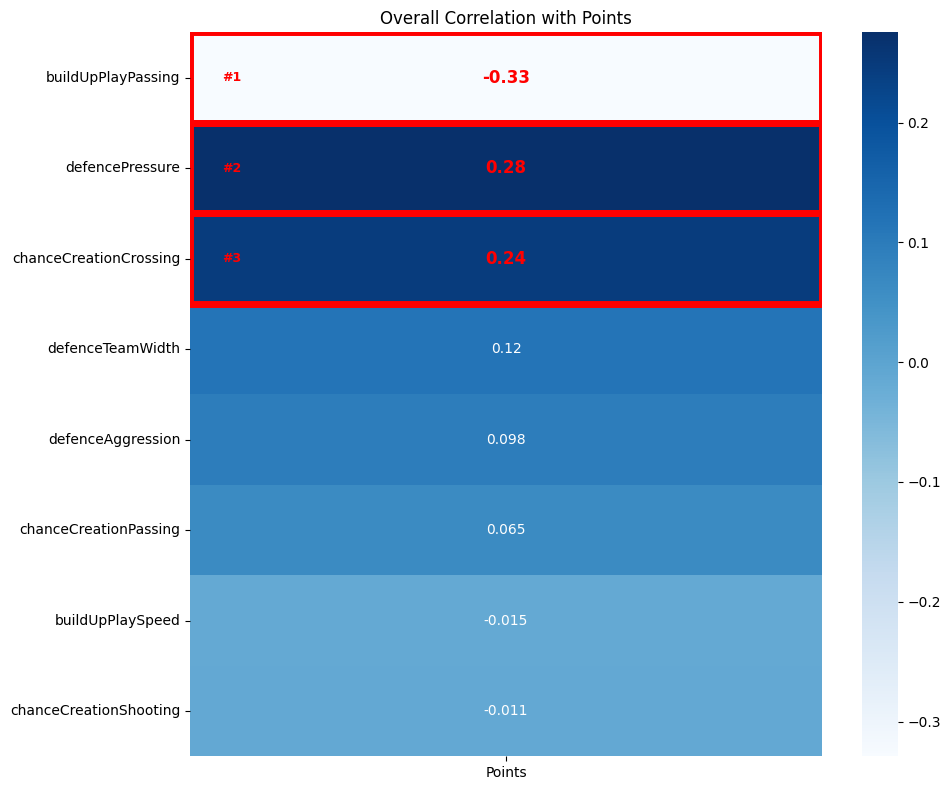

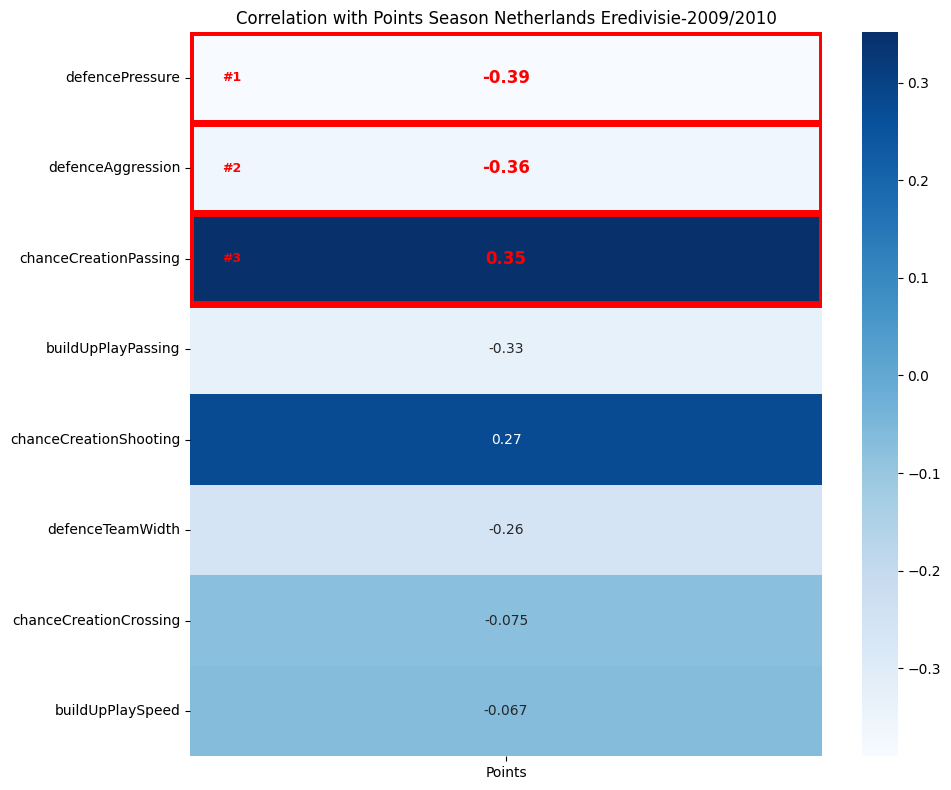

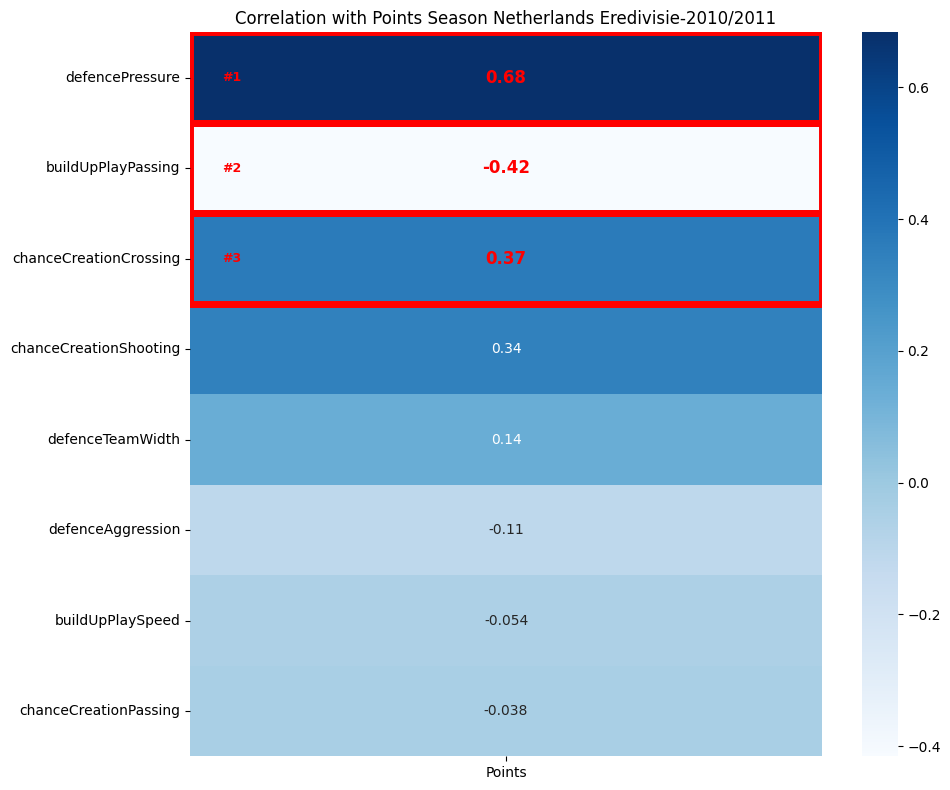

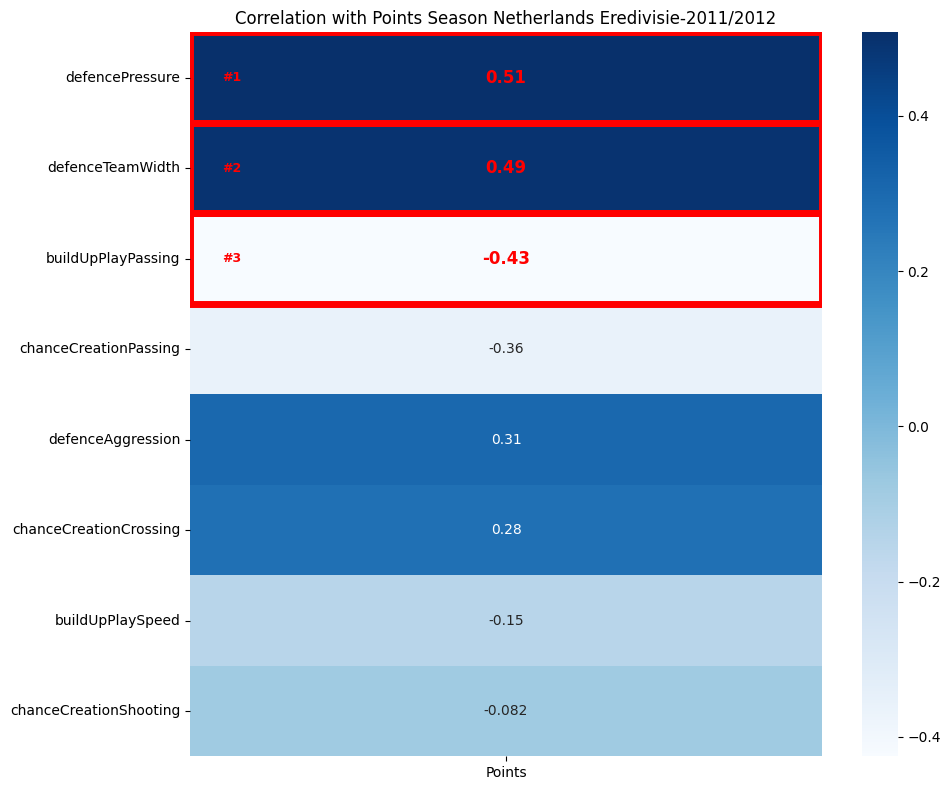

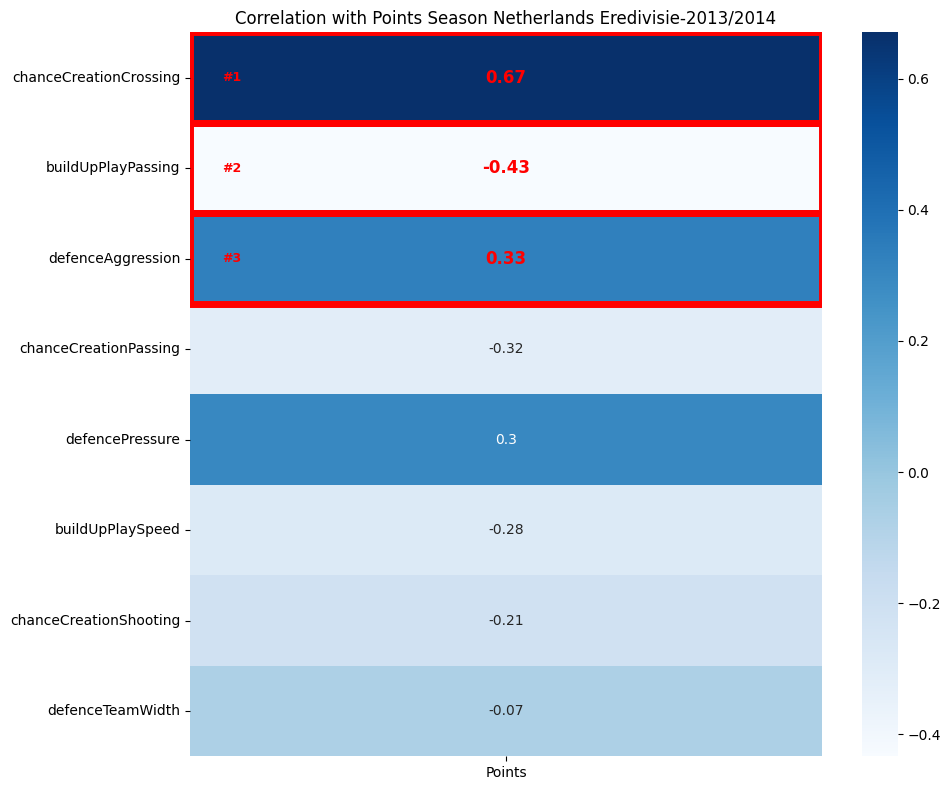

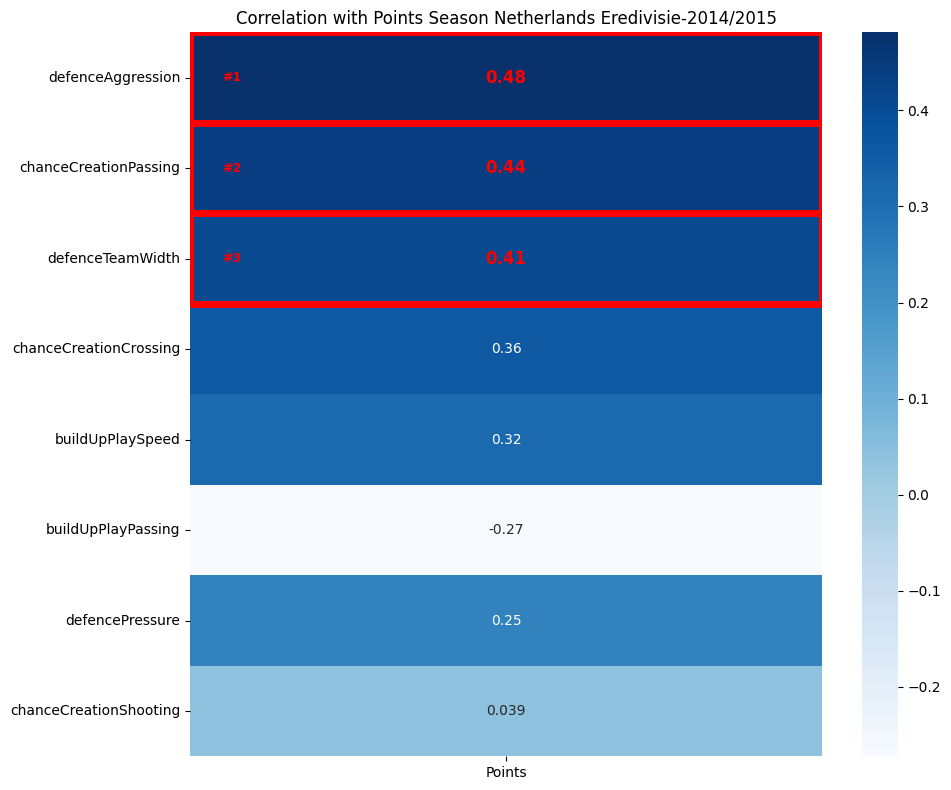

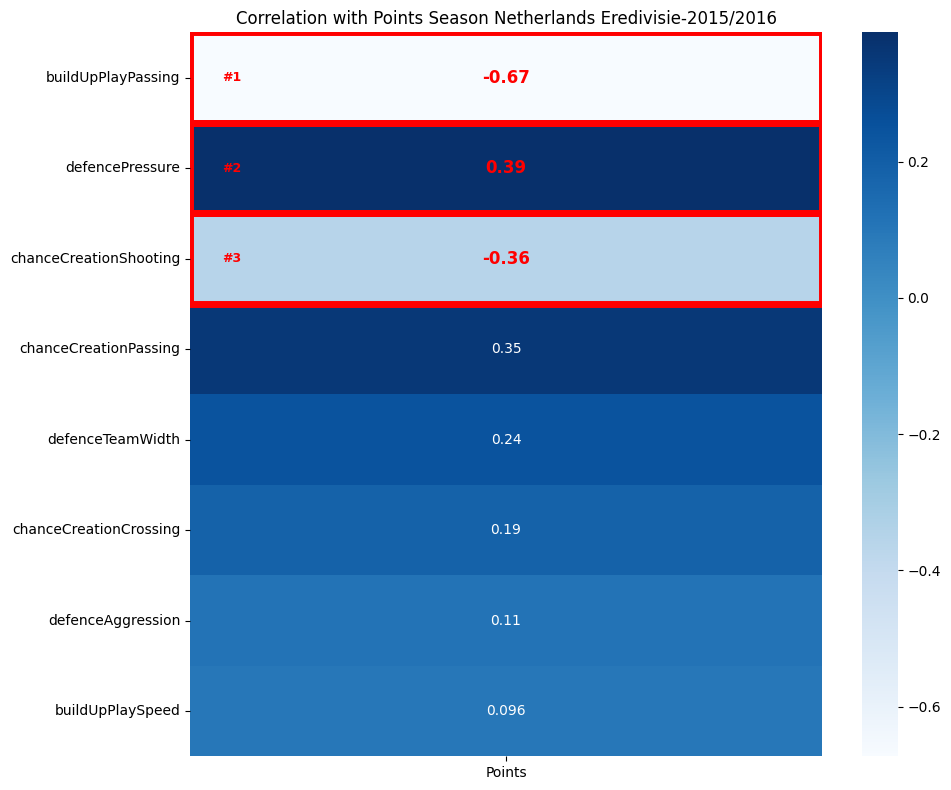

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_correlations(df, season=None):
    """
    Maakt een heatmap van de correlatie tussen numerieke variabelen en het aantal punten.

    De correlaties worden gesorteerd van hoog naar laag op basis van absolute waarde.
    De top 3 sterkste correlaties worden gemarkeerd.

    PARAMETERS:
        - df (pd.DataFrame):
            Dataframe met numerieke kolommen, inclusief 'Points'
        - season (str):
            Seizoen (bijv. '2010/2011'), optioneel voor titel

    RETURNS:
        Toont een heatmap
    """

    # Titel bepalen
    if season is None:
        title = 'Overall Correlation with Points'
    else:
        title = f'Correlation with Points Season {season}'

    # Correlatie berekenen
    corr = df.select_dtypes(include='number').corr()

    # Alleen correlatie met Points
    points_corr = corr[['Points']]

    # Sorteren op absolute waarde
    points_corr = points_corr.reindex(
        points_corr['Points'].abs().sort_values(ascending=False).index
    )

    # Onnodige kolommen verwijderen (veilig)
    for col in ['Points', 'year']:
        if col in points_corr.index:
            points_corr = points_corr.drop(col)

    # Plot maken
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(points_corr, annot=True, cmap='Blues')

    # Top 3 markeren
    for i in range(min(3, len(points_corr))):
        rect = patches.Rectangle((0, i), 1, 1, fill=False, edgecolor='red', linewidth=5)
        ax.add_patch(rect)

        text = ax.texts[i]
        text.set_fontsize(12)
        text.set_color('red')
        text.set_weight('bold')

        ax.text(
            0.05,
            i + 0.5,
            f'#{i+1}',
            va='center',
            ha='left',
            color='red',
            fontsize=9,
            fontweight='bold'
        )

    plt.title(title)
    plt.tight_layout()
    plt.show()


# 1. Overall correlatie
plot_correlations(final_df)


# 2. Per seizoen (CORRECT)
for season, group in final_df.groupby('Season'):
    plot_correlations(group, season=season)

### Interpretatie van de correlaties

**Over alle seizoenen:**
Over alle seizoenen zien we dat *defencePressure* en *chanceCreationCrossing* een positieve relatie hebben met het aantal punten.
*buildUpPlayPassing* lijkt een negatieve relatie te hebben.

Dit betekent dat teams die meer druk zetten en vaker via de zijkanten aanvallen vaak meer punten halen.
Teams die veel passen in de opbouw lijken gemiddeld iets minder succesvol.
Let op: dit is een verband, geen bewijs van oorzaak.

---

**Seizoen 2010/2011:**
In dit seizoen lijkt *chanceCreationPassing* een positieve relatie te hebben met punten.
Teams die kansen creëren via passing doen het relatief goed.

Verdediging lijkt hier minder sterk gerelateerd aan succes dan in andere seizoenen.

---

**Seizoen 2011/2012:**
*defencePressure* heeft hier een duidelijke positieve relatie met punten.
Teams die goed druk zetten, behalen meer punten.

*buildUpPlayPassing* lijkt een negatieve relatie te hebben.

---

**Seizoen 2012/2013:**
Verdedigende eigenschappen zoals *defencePressure* en *defenceTeamWidth* lijken belangrijk.
Teams die goed verdedigen en compact spelen, halen meer punten.

---

**Seizoen 2013/2014:**
*chanceCreationCrossing* heeft hier een positieve relatie met punten.
Aanvallen via de zijkanten lijkt effectief.

Ook verdediging speelt een rol in het succes.

---

**Seizoen 2014/2015:**
Er is geen duidelijke dominante eigenschap.
Meerdere factoren lijken een rol te spelen.

Dit suggereert dat teams die op meerdere vlakken goed zijn, succesvoller zijn.

---

**Seizoen 2015/2016:**
*buildUpPlayPassing* heeft hier een negatieve relatie met punten.
Teams die veel passen in de opbouw lijken minder succesvol.

Druk zetten en aanvallende eigenschappen lijken belangrijker.

---

### Conclusie

Over het algemeen lijken verdedigende eigenschappen zoals *defencePressure* een positieve relatie te hebben met het aantal punten.
Ook aanvallen via de zijkanten (*crossing*) lijkt vaak effectief.

Veel passen in de opbouw (*buildUpPlayPassing*) toont in meerdere seizoenen een negatieve relatie.

Er is geen enkele eigenschap die altijd doorslaggevend is.
Succes hangt waarschijnlijk af van een combinatie van factoren.

**De rode vakken** helpen om de belangrijkste factoren meteen te laten opvallen

De heatmap is gebruikt om snel inzicht te krijgen in de correlaties tussen teamkenmerken en het aantal punten. Door gebruik te maken van kleurverschillen worden sterke en zwakke verbanden direct zichtbaar.


### Relatie tussen teameigenschappen en aantal punten

In [106]:
def scatterplot_corr(df, feature, target, feature_name, target_name):
    '''

    Maakt een regplot (scatterplot met trendlijn) van de feature en de target.
    Geeft ook de correlatie in de legenda.

    PARAMETERS:
        - df (pd.DataFrame):
            De pandas dataframe waarvan de visualisatie gemaakt moet worden.
        - feature (str):
            De naam van de kolomnaam van de feature. Komt op de x-as.
        - target (str):
            De naam van de kolomnaam van de target. Komt op de y-as.
        - feature_name (str):
            De simpele naamgeving van de feature kolom.
        - target_name (str):
            De simpele naamgeving van de target kolom.

    RETURNS:
        sns.regplot van de correlatie tussen feature en target met simpele naamgeving.

    '''

    # Berekent de correlatie tussen de feature en de target en noemt deze corr.
    corr = df[feature].corr(df[target])

    # Maakt een regplot van de data met de kolommen die gegeven zijn als parameters.
    ax = sns.regplot(data= df, 
                    x= feature, 
                    y= target,
                    ci= False,
                    line_kws={"color": "red", "linewidth": 2}
                    )

    # Maakt een titel aan en voegt de legenda toe waarin de correlatie wordt laten zien. 
    plt.xlabel(feature_name)
    plt.ylabel(target_name)
    plt.title(f"Correlatie Tussen {feature_name} en {target_name}")
    ax.legend([f"r = {corr:.2f}"])
    plt.show()

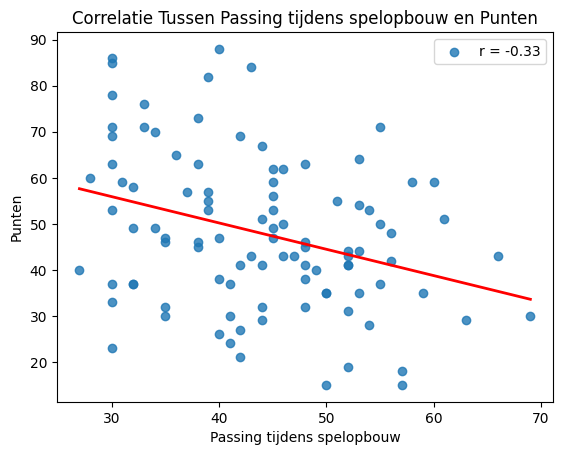

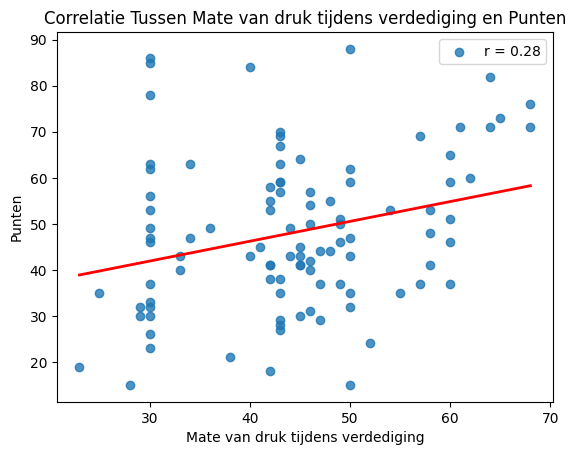

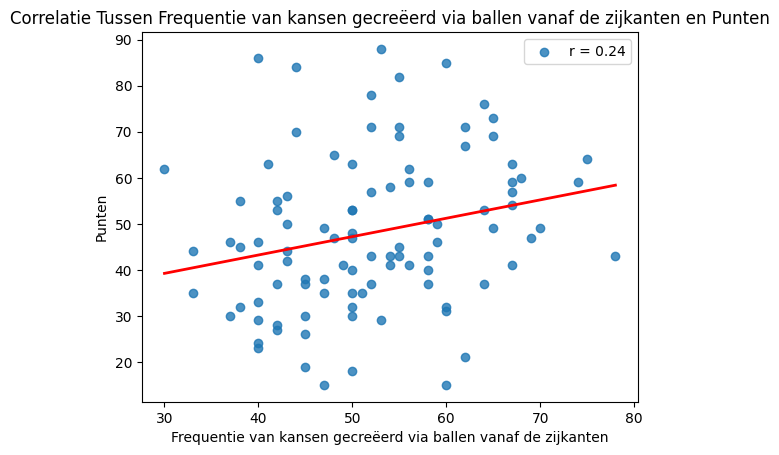

In [107]:
#Gebruiken#

scatterplot_corr(
    df= final_df,
    feature= "buildUpPlayPassing",
    target= "Points",
    feature_name= "Passing tijdens spelopbouw",
    target_name= "Punten"
)

scatterplot_corr(
    df= final_df,
    feature= "defencePressure",
    target= "Points",
    feature_name= "Mate van druk tijdens verdediging",
    target_name= "Punten"
)

scatterplot_corr(
    df= final_df,
    feature= "chanceCreationCrossing",
    target= "Points",
    feature_name= "Frequentie van kansen gecreëerd via ballen vanaf de zijkanten",
    target_name= "Punten"
)


### Interpretatie van de scatterplots

**Relatie tussen passing in de opbouw en punten:**
Deze grafiek heeft een matige negatieve correlatie (r = -0.33). Dit betekent dat teams met een hogere buildUpPlayPassing score gemiddeld iets minder punten halen dan andere teams. Aangezien de helling niet erg steil is, is dit effect zeer beperkt. De punten zijn wijd verspreid, waardoor voorspellingen met deze variabele niet sterk zullen zijn.

---

**Relatie tussen druk zetten en punten:**
Deze grafiek heeft een zwakke positieve correlatie (r = 0.28). Dit betekent dat teams met een hogere defencePressure score gemiddeld iets meer punten halen dan andere teams. Aangezien de helling niet erg steil is, is dit effect zeer beperkt. De punten zijn ook hier heel wijd verspreid, waardoor voorspellingen met deze variabele niet sterk zullen zijn.

---

**Relatie tussen aanvallen via de zijkanten en punten:**
Deze grafiek heeft een zwakke positieve correlatie (r = 0.24). Dit betekent dat teams met een hogere chanceCreationCrossing score gemiddeld iets meer punten halen dan andere teams. Aangezien de helling niet erg steil is, is dit effect zeer beperkt. De punten zijn ook hier heel wijd verspreid, waardoor voorspellingen met deze variabele niet sterk zullen zijn.

---

### Conclusie

Er zijn zwakke verbanden tussen teameigenschappen en het aantal punten.
Druk zetten en aanvallen via de zijkanten hangen samen met iets betere prestaties.
Veel passen in de opbouw hangt samen met iets minder punten.

Geen enkele eigenschap bepaalt het succes alleen.
Succes hangt waarschijnlijk af van meerdere factoren samen.


### Analyse van categoriale teameigenschappen en punten

Free Form komt 9 keer voor in onze data.


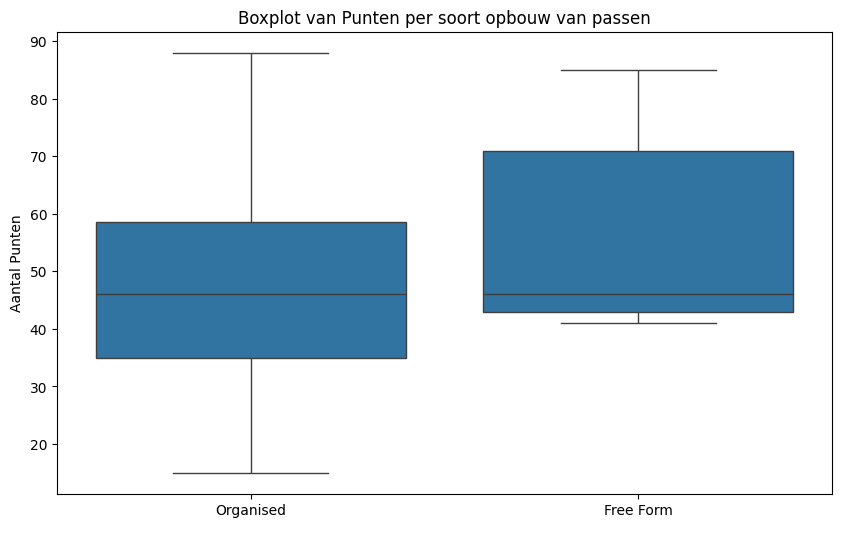

Free Form komt 10 keer voor in onze data.


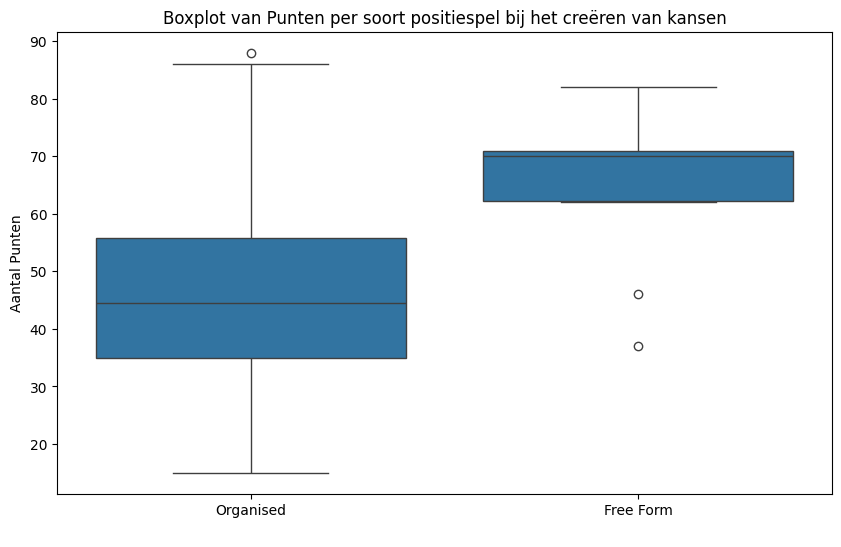

Offside Trap komt 3 keer voor in onze data.


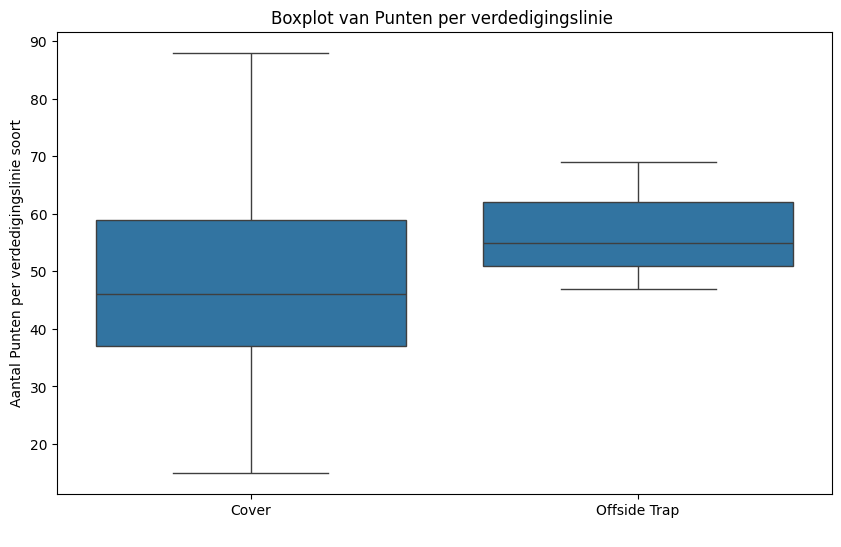

99              Ajax
186             Ajax
191        FC Twente
241        Feyenoord
245           N.E.C.
248    SC Heerenveen
255        NAC Breda
476             Ajax
699          Vitesse
Name: Team, dtype: str

In [108]:
#plot voor buildUpPlayPositioningClass
aantal_free_form = 0
for x in final_df['buildUpPlayPositioningClass']:
    if x =='Free Form':
        aantal_free_form += 1
print(f"Free Form komt {aantal_free_form} keer voor in onze data.")

free_form_teams = final_df.loc[final_df['buildUpPlayPositioningClass'] == 'Free Form', 'Team']

plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, x='buildUpPlayPositioningClass', y='Points')

plt.title('Boxplot van Punten per soort opbouw van passen')
plt.xlabel(' ')
plt.ylabel('Aantal Punten')
plt.show()


#plot voor chanceCreationPositioningClass
aantal_free_form = 0
for x in final_df['chanceCreationPositioningClass']:
    if x =='Free Form':
        aantal_free_form += 1
print(f"Free Form komt {aantal_free_form} keer voor in onze data.")

plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, x='chanceCreationPositioningClass', y='Points')

plt.title('Boxplot van Punten per soort positiespel bij het creëren van kansen')
plt.xlabel(' ')
plt.ylabel('Aantal Punten')
plt.show()


#plot van punten per defenceDefenderLineClass
aantal_offside_trap = 0
for x in final_df['defenceDefenderLineClass']:
    if x =='Offside Trap':
        aantal_offside_trap += 1
print(f"Offside Trap komt {aantal_offside_trap} keer voor in onze data.")

plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, x='defenceDefenderLineClass', y='Points')

plt.title('Boxplot van Punten per verdedigingslinie ')
plt.xlabel(' ')
plt.ylabel('Aantal Punten per verdedigingslinie soort')
plt.show()

display (free_form_teams)

## Analyse van boxplots

We hebben gekozen voor boxplots om categorische data te visualiseren.

### Opbouw van passes (Organised vs Free Form)
In deze plot is te zien dat de kans op een lage hoeveelheid punten kleiner lijkt bij *Free Form* dan bij *Organised*.  
Tegelijkertijd haalt *Free Form* over het algemeen iets meer punten.

Let op: *Free Form* komt maar weinig voor in de dataset (ongeveer 9–10 keer) en bijna alleen door topteams.  
Daardoor kunnen we hier geen sterke conclusie uit trekken.

### Positiespel bij het creëren van kansen
Uit deze boxplot lijkt *Free Form* opnieuw hogere punten te halen dan *Organised*.  

Maar ook hier geldt: deze speelstijl wordt weinig gebruikt (ongeveer 10 gevallen) en bijna alleen door topteams.  
Dus de betrouwbaarheid van deze conclusie is laag.

### Verdedigingsstijl (Cover vs Offside Trap)
De boxplot laat zien dat teams met *Offside Trap* vaak hogere en meer consistente punten halen dan teams met *Cover*.  

Toch is deze strategie maar in een paar gevallen gebruikt (ongeveer 3 keer).  
Hierdoor is de data niet representatief en moeten we voorzichtig zijn met conclusies.

---

## Conclusie

Er zijn verschillen zichtbaar tussen de speelstijlen, maar deze verschillen zijn klein en onzeker.

- *Free Form* lijkt soms beter te presteren dan *Organised*, maar het aantal observaties is te klein.
- *Offside Trap* lijkt consistenter dan *Cover*, maar ook hier is te weinig data.

De groepen overlappen sterk, wat betekent dat deze categorische variabelen geen sterke voorspellers zijn voor het aantal punten.

Waarschijnlijk wordt succes bepaald door een combinatie van meerdere factoren.

## Eindconclusie

Uit de analyse blijkt dat er verbanden zijn tussen teameigenschappen en het aantal punten, maar deze verbanden zijn over het algemeen zwak.

Verdedigende eigenschappen zoals *defencePressure* en aanvallen via de zijkanten (*chanceCreationCrossing*) hangen vaak samen met iets meer punten.
Veel passen in de opbouw (*buildUpPlayPassing*) laat in meerdere gevallen een negatieve relatie zien.

Bij de categoriale variabelen zien we dat *Free Form* vaak iets betere resultaten geeft dan *Organised*, en dat *Offside Trap* consistenter lijkt dan *Cover*.

Toch zijn de verschillen niet groot en is er veel overlap tussen teams.
Dit betekent dat geen enkele eigenschap op zichzelf bepaalt hoeveel punten een team haalt.


# Sprint (4)

### Content :

[Doel van de sprint](#doel-van-de-sprint)

[0a. Teamattributen gekoppeld aan punten & Correlatie](#0a-teamattributen-gekoppeld-aan-punten--correlatie)

[0a. Kolomkeuze – Welke spelereigenschappen tellen echt?](#0a-kolomkeuze--welke-spelereigenschappen-tellen-echt)

[1a. Gemiddelde attributen per speler](#1a-gemiddelde-attributen-per-speler)

[Waarom opdracht 1a opnieuw is gemaakt](#waarom-opdracht-1a-opnieuw-is-gemaakt)

[1b. Spelerratings toegevoegd aan wedstrijden](#1b-spelerratings-toegevoegd-aan-wedstrijden)

[Toelichting opdracht 1b](#toelichting-opdracht-1b)

[Koppeling tussen opdracht 1a en 1b](#koppeling-tussen-opdracht-1a-en-1b)

[1c. Visualisatie: prestaties versus spelerskwaliteit](#1c-visualisatie-prestaties-versus-spelerskwaliteit)


### Doel van deze sprint

Het doel van deze sprint is om te onderzoeken of voetbalclubs in een seizoen hebben gepresteerd zoals verwacht kan worden op basis van de kwaliteit van hun spelers. Hiervoor worden spelersstatistieken gebruikt om te analyseren welke eigenschappen belangrijk zijn voor het voorspellen van wedstrijduitslagen en seizoensprestaties.

Door deze gegevens te koppelen en te visualiseren, kan uiteindelijk worden beoordeeld of teams meer of minder punten hebben behaald dan op basis van hun spelerskwaliteit verwacht mocht worden.

### 0a. Teamattributen gekoppeld aan punten & Correlatie

,season,team_api_id,team_long_name,punten,player_api_id,overall_rating,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,interceptions,positioning,vision,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,2008/2009,6601,FC Volendam,29,57840.890469,64.504979,50.901849,43.604552,47.816501,56.362731,43.349922,54.304410,58.573257,62.544808,62.911807,62.175739,65.317212,63.293935,59.894737,63.944012,65.102418,49.897582,49.211949,53.216174,49.283073,49.029872,44.096423,19.564723,25.927454,34.302987,24.129445,26.378378
1,2008/2009,8277,Vitesse,43,61595.543413,69.055389,52.354291,50.210579,54.323852,60.705589,46.789421,57.846806,62.458583,67.281936,67.289421,64.015968,68.120259,65.713074,57.728044,67.532435,70.610279,53.488523,56.018463,58.164671,46.623752,47.664172,46.867265,17.979541,21.060379,29.840319,20.568363,21.858782
2,2008/2009,8464,N.E.C.,42,38902.552680,68.163586,56.375231,50.847043,53.111830,63.466266,52.947097,59.173290,63.482902,65.512015,65.688540,66.525749,67.891867,64.375000,60.703327,64.180712,68.060536,52.866451,56.872921,61.737360,45.131701,47.282348,46.450375,16.630776,20.126617,27.854436,19.677911,19.447320
3,2008/2009,8525,Willem II,37,57013.771787,65.170370,47.634074,44.910370,60.814074,56.648148,37.921158,51.466667,58.911852,61.780741,63.393333,59.016090,64.240000,61.552695,50.350370,66.391794,69.964444,51.960741,52.640741,55.953339,49.211852,51.908148,49.275141,14.860741,17.290370,25.053333,16.495556,19.445926
4,2008/2009,8526,De Graafschap,30,83504.329384,67.246044,56.952532,55.312500,61.510285,66.172468,56.715243,63.973892,66.904272,67.427215,66.659019,68.940536,66.412184,66.641541,65.753956,64.547739,67.764241,50.482595,59.962025,61.432998,46.673259,47.959652,46.644054,10.390032,10.287975,15.143987,10.797468,11.684335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2015/2016,10217,ADO Den Haag,43,118826.292160,67.001029,52.637674,45.887974,55.412935,61.101733,44.900498,58.791216,61.961057,67.108767,67.776119,63.511923,64.701149,61.335735,58.109281,67.509521,66.465775,52.017327,52.554469,54.011837,50.009264,51.250300,48.743352,13.787957,15.806142,18.587065,15.144793,16.967919
140,2015/2016,10218,Excelsior,30,164275.017287,64.500963,47.867597,47.432114,53.060183,60.084738,43.530573,54.271786,59.717140,63.407800,61.686326,62.139143,62.146124,64.551035,58.233269,66.927780,65.900818,49.026481,51.641550,53.324988,47.488445,47.716177,47.710881,15.841598,16.562109,20.861338,15.515888,16.532740
141,2015/2016,10228,SC Heerenveen,42,291795.387864,65.444602,48.767533,44.798109,47.593538,58.025690,45.623168,58.480536,61.408038,70.097400,69.488101,64.456895,59.205831,64.852009,57.627266,67.557762,64.484476,44.127502,47.178093,51.839243,43.391174,46.290307,44.486998,17.618913,17.201891,18.012766,16.063515,18.022222
142,2015/2016,10229,AZ,59,280961.578906,67.474066,51.665931,48.660728,53.106101,64.473120,47.175311,61.988807,65.868989,69.618319,69.325871,68.813968,63.150087,65.629040,66.755478,63.537601,67.982658,52.405329,55.885543,59.476431,52.624783,53.126439,52.357560,14.627936,14.165222,17.242945,13.998739,15.311367


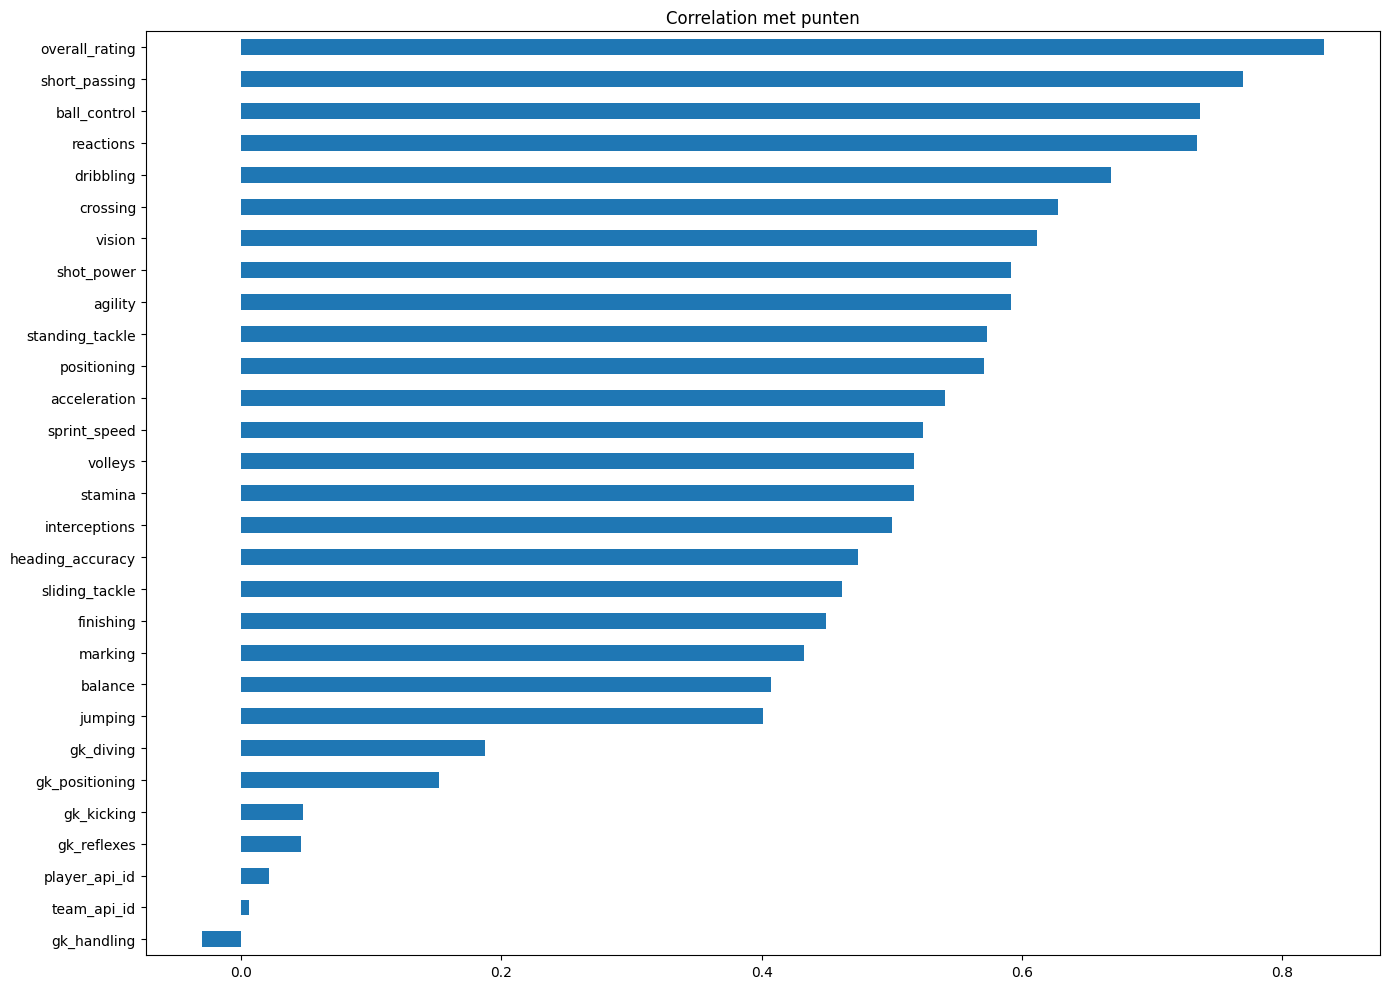

In [109]:
class EredivisiePlayerAnalysis:
    """
    Analyse van Eredivisie teams met:
    - punten
    - gemiddelde speler attributen per team per seizoen
    """

    def __init__(self, conn):
        """
        Initialiseert met database connectie.

        Parameters:
        conn : sqlite3.Connection
        """
        self.conn = conn


    # Points
    def get_points(self):
        """
        Berekent punten per team per seizoen.

        Returns:
        pandas.DataFrame
        """
        query = """
        SELECT 
            m.season,
            t.team_api_id,
            t.team_long_name,
            SUM(
                CASE 
                    WHEN m.home_team_api_id = t.team_api_id AND m.home_team_goal > m.away_team_goal THEN 3
                    WHEN m.away_team_api_id = t.team_api_id AND m.away_team_goal > m.home_team_goal THEN 3
                    WHEN m.home_team_goal = m.away_team_goal THEN 1
                    ELSE 0
                END
            ) AS punten
        FROM Match m
        JOIN League l ON m.league_id = l.id
        JOIN Team t 
            ON t.team_api_id = m.home_team_api_id 
            OR t.team_api_id = m.away_team_api_id
        WHERE l.name = 'Netherlands Eredivisie'
        GROUP BY m.season, t.team_api_id
        """
        return pd.read_sql(query, self.conn)


    # Player attributes (aggregated)
    def get_player_attributes_team(self):
        """
        Zet player attributen om naar team niveau
        door gemiddelde per team per seizoen te nemen.

        Returns:
        pandas.DataFrame
        """

        # Match + players (alle spelers per wedstrijd)
        match_players = pd.read_sql("""
        SELECT
            m.season,
            m.home_team_api_id,
            m.away_team_api_id,

            m.home_player_1, m.home_player_2, m.home_player_3,
            m.home_player_4, m.home_player_5, m.home_player_6,
            m.home_player_7, m.home_player_8, m.home_player_9,
            m.home_player_10, m.home_player_11,

            m.away_player_1, m.away_player_2, m.away_player_3,
            m.away_player_4, m.away_player_5, m.away_player_6,
            m.away_player_7, m.away_player_8, m.away_player_9,
            m.away_player_10, m.away_player_11

        FROM Match m
        JOIN League l ON m.league_id = l.id
        WHERE l.name = 'Netherlands Eredivisie'
        """, self.conn)

        # Maak long format (één speler per rij)
        players = []

        for _, row in match_players.iterrows():
            season = row['season']

            # Home team
            for i in range(1, 12):
                pid = row[f'home_player_{i}']
                if pid:
                    players.append((season, row['home_team_api_id'], pid))

            # Away team
            for i in range(1, 12):
                pid = row[f'away_player_{i}']
                if pid:
                    players.append((season, row['away_team_api_id'], pid))

        players_df = pd.DataFrame(players, columns=['season', 'team_api_id', 'player_api_id'])

        # Player attributes
        player_attr = pd.read_sql("""
        SELECT
        player_api_id,
        overall_rating,
        crossing,
        finishing,
        heading_accuracy,
        short_passing,
        volleys,
        dribbling,
        ball_control,
        acceleration,
        sprint_speed,
        agility,
        reactions,
        balance,
        shot_power,
        jumping,
        stamina,
        interceptions,
        positioning,
        vision,
        marking,
        standing_tackle,
        sliding_tackle,
        gk_diving,
        gk_handling,
        gk_kicking,
        gk_positioning,
        gk_reflexes
        FROM Player_Attributes
        """, self.conn)

        # Merge players + attributes
        df = players_df.merge(player_attr, on='player_api_id', how='inner')

        # Aggregate → team per season
        df_team = df.groupby(['season', 'team_api_id']).mean(numeric_only=True).reset_index() ## average player quality per team!!!

        return df_team


    # Combine
    def combine(self):
        """
        Combineert punten met team speler attributen.

        Returns:
        pandas.DataFrame
        """

        points = self.get_points()
        player_stats = self.get_player_attributes_team()

        df = points.merge(
            player_stats,
            on=['season', 'team_api_id'],
            how='inner'
        )

        return df


# Gebruik
analysis = EredivisiePlayerAnalysis(conn)

df_points_player_att = analysis.combine()

display(df_points_player_att)

# Correlatie
corr = df_points_player_att.corr(numeric_only=True)['punten'].sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(14, 10))

corr.drop('punten').plot(kind='barh', ax=ax)

ax.set_title("Correlation met punten")

plt.tight_layout()
plt.show()

#### 0a. Kolomkeuze – Welke spelereigenschappen tellen echt?

Voor opdracht 0a kiezen we bewust alleen de kolommen die echt iets zeggen over de kwaliteit van een speler.

##### Niet gebruikt: ID’s en metadata

`id`, `date`, `player_fifa_api_id`, `player_api_id`
→ Deze kolommen identificeren alleen spelers of tijd. Ze zeggen niets over prestaties.

##### Niet gebruikt: zeldzame situaties

* `free_kick_accuracy` → alleen bij vrije trappen
* `penalties` → alleen bij penalty’s

→ Deze momenten komen weinig voor. Ze geven geen goed beeld van de totale kwaliteit.

##### Niet gebruikt: tekstkolommen

* `preferred_foot`
* `attacking_work_rate`, `defensive_work_rate`

→ Dit zijn geen cijfers. Je kan hier geen gemiddelde of correlatie mee berekenen.

---

##### Wel gebruikt: vaardigheden die wedstrijden bepalen

* **Algemeen**: `overall_rating`
* **Aanval**: `finishing`, `volleys`, `shot_power`, `crossing`, `heading_accuracy`
* **Opbouw**: `short_passing`, `ball_control`, `dribbling`, `vision`, `positioning`
* **Fysiek**: `acceleration`, `sprint_speed`, `agility`, `balance`, `jumping`, `stamina`, `reactions`
* **Verdediging**: `marking`, `standing_tackle`, `sliding_tackle`, `interceptions`
* **Keeper**: `gk_diving`, `gk_handling`, `gk_kicking`, `gk_positioning`, `gk_reflexes`

---

#### Conclusie

We gebruiken alleen kolommen die direct invloed hebben op prestaties in een wedstrijd.
Alles wat ruis geeft of weinig impact heeft, laten we weg.


## 1a. Gemiddelde attributen per speler

In [110]:
import pandas as pd

class PlayerAnalysis:
    """
    Analyse op speler-niveau:
    per speler het gemiddelde van relevante spelerseigenschappen.
    """

    def __init__(self, conn):
        self.conn = conn

    def get_player_attributes_avg(self):
        """
        Maakt een dataframe met per speler het gemiddelde
        van relevante spelerattributen.

        Returns:
            pandas.DataFrame
        """
        query = """
        SELECT
            player_api_id,
            overall_rating,
            crossing,
            finishing,
            heading_accuracy,
            short_passing,
            volleys,
            dribbling,
            ball_control,
            acceleration,
            sprint_speed,
            agility,
            reactions,
            balance,
            shot_power,
            jumping,
            stamina,
            interceptions,
            positioning,
            vision,
            marking,
            standing_tackle,
            sliding_tackle,
            gk_diving,
            gk_handling,
            gk_kicking,
            gk_positioning,
            gk_reflexes
        FROM Player_Attributes
        """
        df = pd.read_sql(query, self.conn)

        # Gemiddelde per speler
        df_player_avg = (
            df.groupby("player_api_id", as_index=False)
              .mean(numeric_only=True)
        )

        return df_player_avg

### Waarom opdracht 1a opnieuw is gemaakt

Opdracht 1a is opnieuw gemaakt omdat de eerdere versie de data samenvoegde op **teamniveau** in plaats van op **spelerniveau**.

In de eerste uitwerking werden de spelerattributen uiteindelijk gemiddeld per **team** en per **seizoen**. Dat was bruikbaar voor een analyse van teamprestaties, maar niet voor opdracht 1b. In opdracht 1b moet namelijk per wedstrijd zichtbaar zijn wat de gemiddelde `overall_rating` is van **elke speler** in de wedstrijd.

Daarvoor is een dataframe nodig waarin iedere rij bij één speler hoort, met daarbij zijn gemiddelde eigenschappen uit `Player_Attributes`. In de oude versie van opdracht 1a was die informatie niet meer direct beschikbaar, omdat de spelers al waren samengevoegd tot teamgemiddelden.

Daarom is opdracht 1a opnieuw opgebouwd, zodat het nieuwe dataframe per `player_api_id` het gemiddelde van de relevante spelerseigenschappen bevat. Dit nieuwe dataframe kan daarna in opdracht 1b gebruikt worden om de gemiddelde `overall_rating` van iedere speler aan het `Match` dataframe toe te voegen.

## 1b. Spelerratings toegevoegd aan wedstrijden

In [111]:
class MatchPlayerOverallAnalysis:
    """
    Analyse van wedstrijden waarbij per speler in de match
    de speler attribuut aanwezig is.
    """

    def __init__(self, conn, df_player_avg, player_attribute):
        """
        Initialisatie met alle self attributen die deze class gebruikt.

        PARAMETERS:
        - conn (sqlite3.Connection):
            connectie met de database
        - df_player_avg (pandas.DataFrame):
            dataframe met speler id en speler attribuut
        - player_attribute (string): 
            kolomnaam van speler attribuut.
        """
        self.conn = conn
        self.df_player_avg = df_player_avg
        self.player_attribute = player_attribute

    def get_match_df(self):
        """
        Haalt het match dataframe op voor de Eredivisie.

        Returns:
            pandas.DataFrame met gegevens van Match tabel
        """
        query = """
        SELECT
            m.id,
            m.country_id,
            m.league_id,
            m.season,
            m.stage,
            m.date,
            m.match_api_id,
            m.home_team_api_id,
            m.away_team_api_id,
            m.home_team_goal,
            m.away_team_goal,

            m.home_player_1, m.home_player_2, m.home_player_3,
            m.home_player_4, m.home_player_5, m.home_player_6,
            m.home_player_7, m.home_player_8, m.home_player_9,
            m.home_player_10, m.home_player_11,

            m.away_player_1, m.away_player_2, m.away_player_3,
            m.away_player_4, m.away_player_5, m.away_player_6,
            m.away_player_7, m.away_player_8, m.away_player_9,
            m.away_player_10, m.away_player_11

        FROM Match m
        JOIN League l
            ON m.league_id = l.id
        WHERE l.name = 'Netherlands Eredivisie'
        """
        return pd.read_sql(query, self.conn)

    def add_player_attribute(self):
        """
        Voegt voor iedere speler in iedere wedstrijd
        de speler attribuut toe.

        Returns:
            match_df (pandas.DataFrame):
                dataframe met match gegevens en home en away speler attributen
        """
        match_df = self.get_match_df()

        # Alleen player_api_id + overall_rating uit 1a nodig
        rating_df = self.df_player_avg[["player_api_id", f"{self.player_attribute}"]].copy()

        # Home spelers
        for i in range(1, 12):
            match_df = match_df.merge(
                rating_df.rename(columns={
                    "player_api_id": f"home_player_{i}",
                    f"{self.player_attribute}": f"home_player_{i}_{self.player_attribute}"
                }),
                on=f"home_player_{i}",
                how="left"
            )

        # Away spelers
        for i in range(1, 12):
            match_df = match_df.merge(
                rating_df.rename(columns={
                    "player_api_id": f"away_player_{i}",
                    f"{self.player_attribute}": f"away_player_{i}_{self.player_attribute}"
                }),
                on=f"away_player_{i}",
                how="left"
            )

        return match_df

In [112]:
# Opdracht 1a
player_analysis = PlayerAnalysis(conn)
df_player_avg = player_analysis.get_player_attributes_avg()

display(df_player_avg)

# Opdracht 1b
match_analysis = MatchPlayerOverallAnalysis(conn, df_player_avg, "overall_rating")
match_df_with_ratings = match_analysis.add_player_attribute()

match_analysis = MatchPlayerOverallAnalysis(conn, df_player_avg, "short_passing")
match_df_with_passings = match_analysis.add_player_attribute()

display(match_df_with_ratings.head())
print(match_df_with_ratings.shape)

,player_api_id,overall_rating,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,interceptions,positioning,vision,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,2625,60.142857,50.142857,47.285714,46.285714,56.500000,38.000000,54.142857,59.142857,66.857143,63.285714,66.428571,49.714286,66.214286,66.714286,58.714286,77.285714,62.071429,50.357143,55.285714,62.928571,63.857143,56.571429,12.428571,12.857143,19.071429,10.357143,10.428571
1,2752,69.380952,36.428571,37.428571,75.333333,54.809524,20.428571,44.857143,55.571429,41.619048,42.190476,43.333333,60.857143,44.571429,57.428571,56.523810,60.904762,71.428571,31.428571,52.428571,71.095238,70.666667,65.571429,11.095238,6.095238,7.095238,9.095238,15.095238
2,2768,69.285714,42.238095,42.761905,66.666667,64.714286,28.761905,40.238095,56.380952,56.952381,58.904762,58.047619,69.809524,60.190476,38.761905,76.904762,59.285714,74.714286,44.190476,57.761905,71.666667,70.619048,79.714286,10.761905,15.904762,22.714286,15.142857,12.095238
3,2770,71.133333,61.866667,67.666667,67.800000,72.533333,67.133333,75.066667,76.733333,62.200000,59.800000,62.600000,65.933333,61.266667,68.333333,57.133333,51.000000,44.933333,64.533333,71.600000,30.200000,37.533333,25.000000,8.666667,15.666667,27.200000,16.333333,17.000000
4,2790,70.200000,70.000000,37.400000,55.200000,68.000000,43.000000,60.800000,66.800000,70.800000,71.200000,65.000000,69.200000,67.000000,46.400000,61.000000,70.400000,63.400000,60.600000,60.000000,74.600000,74.600000,69.000000,8.000000,17.000000,59.000000,16.600000,17.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11055,744907,51.909091,42.454545,44.454545,47.454545,59.454545,42.454545,56.454545,55.454545,66.000000,64.000000,61.000000,53.454545,74.000000,50.454545,63.000000,54.000000,22.454545,48.454545,51.454545,39.454545,48.454545,49.454545,8.454545,13.454545,12.454545,11.454545,8.454545
11056,746419,59.000000,55.000000,28.000000,50.000000,35.000000,29.000000,67.000000,55.000000,77.000000,76.000000,70.000000,60.000000,74.000000,29.000000,55.000000,63.000000,53.000000,55.000000,40.000000,55.000000,69.000000,62.000000,7.000000,10.000000,7.000000,9.000000,9.000000
11057,748432,58.000000,48.000000,26.000000,57.000000,49.000000,24.000000,41.000000,42.000000,64.000000,68.000000,50.000000,48.000000,52.000000,46.000000,68.000000,50.000000,55.000000,38.000000,36.000000,63.000000,69.000000,68.000000,8.000000,8.000000,12.000000,12.000000,6.000000
11058,750435,56.444444,35.000000,57.000000,55.000000,60.000000,52.000000,58.555556,56.333333,65.666667,63.555556,60.222222,61.000000,78.000000,57.000000,58.000000,57.000000,13.000000,56.333333,58.000000,18.000000,19.000000,21.000000,9.000000,10.000000,8.000000,10.000000,11.000000


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,home_player_1_overall_rating,home_player_2_overall_rating,home_player_3_overall_rating,home_player_4_overall_rating,home_player_5_overall_rating,home_player_6_overall_rating,home_player_7_overall_rating,home_player_8_overall_rating,home_player_9_overall_rating,home_player_10_overall_rating,home_player_11_overall_rating,away_player_1_overall_rating,away_player_2_overall_rating,away_player_3_overall_rating,away_player_4_overall_rating,away_player_5_overall_rating,away_player_6_overall_rating,away_player_7_overall_rating,away_player_8_overall_rating,away_player_9_overall_rating,away_player_10_overall_rating,away_player_11_overall_rating
0,13274,13274,13274,2008/2009,1,2008-08-29 00:00:00,508287,8277,8674,0,4,37216.0,26618.0,37211.0,26708.0,45852.0,114688.0,NaN,41295.0,NaN,NaN,26612.0,36846.0,45500.0,30424.0,26465.0,30824.0,26469.0,45462.0,33625.0,26699.0,33039.0,39141.0,73.291667,72.400000,66.111111,65.350000,64.875000,71.615385,NaN,67.166667,NaN,NaN,70.133333,69.533333,64.888889,75.590909,69.272727,68.903226,66.666667,69.272727,68.777778,67.222222,65.941176,74.000000
1,13275,13274,13274,2008/2009,1,2008-08-30 00:00:00,508303,9803,8611,1,1,26589.0,41005.0,26683.0,38380.0,26587.0,109061.0,45879.0,45466.0,37978.0,NaN,26590.0,40916.0,27177.0,40153.0,110147.0,26489.0,26538.0,32690.0,38373.0,26520.0,26544.0,26675.0,65.666667,68.818182,65.111111,67.285714,65.307692,70.709677,69.111111,67.846154,66.142857,NaN,68.160000,71.714286,63.555556,68.315789,75.592593,70.956522,71.650000,64.611111,76.166667,67.714286,75.571429,75.500000
2,13276,13274,13274,2008/2009,1,2008-08-30 00:00:00,508304,8525,8593,2,1,42710.0,45488.0,26637.0,45485.0,NaN,27367.0,33684.0,NaN,33685.0,45830.0,26519.0,30841.0,26468.0,37643.0,26005.0,37762.0,33683.0,26459.0,30603.0,40636.0,36784.0,45174.0,67.600000,61.714286,65.666667,64.666667,NaN,61.818182,66.800000,NaN,66.619048,66.263158,68.428571,78.629630,67.750000,76.166667,79.606061,78.925926,70.444444,68.272727,75.550000,85.275000,82.714286,73.500000
3,13277,13274,13274,2008/2009,1,2008-08-30 00:00:00,508305,8464,8526,2,0,26510.0,26532.0,NaN,30880.0,92527.0,42715.0,39213.0,26674.0,45473.0,NaN,41596.0,NaN,NaN,30475.0,9149.0,26608.0,NaN,45917.0,26642.0,45922.0,NaN,38262.0,70.050000,71.176471,NaN,65.000000,66.181818,63.800000,73.600000,67.454545,65.900000,NaN,66.590909,NaN,NaN,65.000000,64.666667,64.125000,NaN,61.250000,64.000000,56.500000,NaN,68.133333
4,13278,13274,13274,2008/2009,1,2008-08-30 00:00:00,508306,9908,8640,1,5,37193.0,26498.0,37753.0,26503.0,110150.0,26781.0,NaN,18533.0,26505.0,73447.0,NaN,36617.0,34479.0,41165.0,36123.0,37194.0,26434.0,26440.0,145586.0,39359.0,26451.0,46120.0,77.920000,64.714286,65.388889,68.100000,61.000000,71.384615,NaN,65.272727,67.000000,65.714286,NaN,75.173913,72.500000,69.120000,71.315789,71.652174,77.928571,74.571429,65.636364,71.062500,71.266667,75.848485


(2448, 55)


## Toelichting opdracht 1b

In dit codeblok wordt het `Match` dataframe van de Eredivisie opgehaald. Dit dataframe bevat per wedstrijd informatie zoals het seizoen, de datum, de teams, het aantal doelpunten en de spelers die hebben meegedaan.

Daarna wordt de informatie uit opdracht 1a gebruikt. In opdracht 1a is per speler al het gemiddelde van een gekozen spelerattribuut berekend, bijvoorbeeld `overall_rating`. Deze gegevens staan in het dataframe `df_player_avg`.

Vervolgens koppelen we dit spelerattribuut aan het `Match` dataframe. Dat gebeurt apart voor alle thuisspelers (`home_player_1` tot en met `home_player_11`) en voor alle uitspelers (`away_player_1` tot en met `away_player_11`).

Voor elke spelerkolom wordt een merge uitgevoerd met het dataframe uit opdracht 1a. Zo krijgt elke speler in de wedstrijd een extra kolom met zijn gemiddelde attribuut. Bijvoorbeeld:
- `home_player_1_overall_rating`
- `home_player_2_overall_rating`
- `away_player_1_overall_rating`

Op deze manier wordt het `Match` dataframe uitgebreid met extra informatie over de kwaliteit van elke speler die in de wedstrijd heeft meegedaan.

### Koppeling tussen opdracht 1a en 1b

Opdracht 1a levert per speler één gemiddelde waarde van een attribuut op.  
Opdracht 1b gebruikt deze informatie om die waarde toe te voegen aan elke wedstrijd waarin de speler voorkomt.

Dus:
- opdracht 1a berekent het gemiddelde attribuut per speler
- opdracht 1b koppelt dat attribuut aan alle spelers in het `Match` dataframe

Hierdoor kunnen we later per wedstrijd verder analyseren welke rol spelerkwaliteit speelt.

## 1c. Visualisatie: prestaties versus spelerskwaliteit

### De correlatie tussen een spelerattribuut en behaalde punten per team en seizoen.

In [113]:
class CorrelationPlayerAttributes:
    """
    Berekent de correlatie tussen een gegeven speler attribuut en punten.

    Voorbeeld gebruik:

        player_attribute = CorrelationPlayerAttributes(match_df_with_player_attribute, "attribute name")
        player_attribute.calc_pl_attribute_per_team_season()
        player_attribute.api_id_to_team_name()
        player_attribute.calculate_correlation_per_season(board.leaderboards)
        player_attribute.display_correlation_info()
    """

    def __init__(self, df, player_attribute):
        """
        PARAMETERS:
            - df (pandas.DataFrame):
                Match gegevens + speler attribuut score per speler.
            - player_attribute (str):
                Kolomnaam van speler attribuut.
        """

        self.df = df
        self.player_attribute = player_attribute

        self.df_melted_mean_pl_attribute = pd.DataFrame([])
        self.overall_correlation = 0
        self.corr_df = pd.DataFrame([])
        self.df_placement_plus_attribute = pd.DataFrame([])

    def calc_pl_attribute_per_team_season(self):
        """
        Berekent gemiddelde speler attribuut per team per seizoen.
        """

        home_player_cols = [
            f'home_player_{i}_{self.player_attribute}'
            for i in range(1, 12)
        ]

        away_player_cols = [
            f'away_player_{i}_{self.player_attribute}'
            for i in range(1, 12)
        ]

        # Home team dataframe
        home_df = self.df[['season', 'home_team_api_id'] + home_player_cols].copy()

        home_df = home_df.rename(
            columns={'home_team_api_id': 'team_api_id'}
        )

        home_df = home_df.melt(
            id_vars=['season', 'team_api_id'],
            value_vars=home_player_cols,
            var_name='player',
            value_name=self.player_attribute
        )

        # Away team dataframe
        away_df = self.df[['season', 'away_team_api_id'] + away_player_cols].copy()

        away_df = away_df.rename(
            columns={'away_team_api_id': 'team_api_id'}
        )

        away_df = away_df.melt(
            id_vars=['season', 'team_api_id'],
            value_vars=away_player_cols,
            var_name='player',
            value_name=self.player_attribute
        )

        # Combineer home en away
        combined_df = pd.concat(
            [home_df, away_df],
            ignore_index=True
        )

        # Gemiddelde speler attribuut per team per seizoen
        new_df = combined_df.groupby(
            ['season', 'team_api_id']
        )[self.player_attribute].mean()

        self.df_melted_mean_pl_attribute = new_df

    def api_id_to_team_name(self):
        """
        Zet team_api_id om naar team naam.
        """

        df_reset = self.df_melted_mean_pl_attribute.reset_index()

        team_ids = df_reset['team_api_id'].unique().tolist()

        placeholders = ",".join(["?"] * len(team_ids))

        query = f"""
        SELECT team_api_id, team_long_name
        FROM Team
        WHERE team_api_id IN ({placeholders})
        """

        result = pd.read_sql(
            query,
            conn,
            params=team_ids
        )

        # Voeg team namen toe
        df_reset = df_reset.merge(
            result,
            on='team_api_id',
            how='left'
        )

        df_team_names = df_reset.drop(
            columns='team_api_id'
        ).rename(
            columns={
                'team_long_name': 'Team',
                'season': 'Season'
            }
        )

        self.df = df_team_names

    def calculate_correlation_per_season(self, df_points):
        """
        Berekent correlatie tussen speler attribuut en punten.
        """

        player_attribute_list = self.df

        # Maak leaderboard dataframe
        leaderboards_df = pd.concat(
            df_points.values(),
            ignore_index=True
        )

        # Merge punten + speler attribuut
        new_dataframe_list = leaderboards_df.merge(
            player_attribute_list,
            on=['Team', 'Season'],
            how='left'
        )

        # Algemene correlatie
        overall_correlation = new_dataframe_list[
            self.player_attribute
        ].corr(
            new_dataframe_list['Points']
        )

        # Correlatie per seizoen
        correlation_per_season = new_dataframe_list.groupby(
            'Season'
        ).apply(
            lambda x: x[self.player_attribute].corr(x['Points']),
            include_groups=False
        )

        self.df_placement_plus_attribute = new_dataframe_list
        self.corr_df = correlation_per_season
        self.overall_correlation = overall_correlation

    def display_correlation_info(self):
        """
        Print informatie over de correlatie.
        """

        print(
            f"Correlatie tussen gemiddelde "
            f"{self.player_attribute} "
            f"per team per seizoen en het aantal punten:"
        )

        print(
            f"Algemene correlatie: "
            f"{self.overall_correlation:.3f}"
        )

        display(self.corr_df)

In [114]:
overall_rating = CorrelationPlayerAttributes(
    match_df_with_ratings,
    "overall_rating"
)

overall_rating.calc_pl_attribute_per_team_season()
overall_rating.api_id_to_team_name()
overall_rating.calculate_correlation_per_season(board.leaderboards)

overall_rating.display_correlation_info()


short_passing = CorrelationPlayerAttributes(
    match_df_with_passings,
    "short_passing"
)

short_passing.calc_pl_attribute_per_team_season()
short_passing.api_id_to_team_name()
short_passing.calculate_correlation_per_season(board.leaderboards)

short_passing.display_correlation_info()

Correlatie tussen gemiddelde overall_rating per team per seizoen en het aantal punten:
Algemene correlatie: 0.862


Season
2008/2009    0.857899
2009/2010    0.943120
2010/2011    0.812712
2011/2012    0.942299
2012/2013    0.925467
2013/2014    0.920058
2014/2015    0.897290
2015/2016    0.876427
dtype: float64

Correlatie tussen gemiddelde short_passing per team per seizoen en het aantal punten:
Algemene correlatie: 0.816


Season
2008/2009    0.784125
2009/2010    0.858001
2010/2011    0.829970
2011/2012    0.853713
2012/2013    0.833695
2013/2014    0.841102
2014/2015    0.857993
2015/2016    0.798196
dtype: float64

### Statistiek 1 – Overall Rating vs. Punten

De eerste visualisatie toont de relatie tussen de **gemiddelde overall rating** van alle spelers
die in het seizoen 2015/2016 voor een team hebben gespeeld, en het **totaal aantal punten** dat
het team heeft behaald.

In [115]:
def plot_points_vs_stat(df_combined, stat_col, stat_label, league_name, season, team_name, team_color, team_color_outline):
    """
    Plot de punten samen met de speler attribuut met een correlatielijn tussen de twee voor elk team.

    PARAMETERS:
        - df_combined (pandas.DataFrame):
            dataframe waarbij de punten, de teams en speler attribuut aanwezig zijn.
        - stat_col (str):
            kolomnaam van correlerende waarde met punten.
        - stat_label (str):
            nette naam van de kolomnaam
        - league_name (str):
            naam van de league waarin de correlatie gezocht wordt.
        - season (str):
            seizoen waarin de correlatie gezocht wordt.
        - team_name (str):
            naam van de team die een andere kleur krijgt.
        - team_color (str):
            de binnenkant van de kleur van het team.
        - team_color_outline (str):
            de rand van de kleur van het team.

    RETURNS:
        lijnplot met scatters van elk team met punten, speler attribuut en correlatie.
    """

    corr = df_combined[stat_col].corr(df_combined['Points'])

    fig, ax = plt.subplots(figsize=(14, 8))

    sns.regplot(
        data=df_combined,
        x=stat_col,
        y='Points',
        ax=ax,
        ci=False,
        scatter_kws={'s': 90, 'zorder': 3},
        line_kws={'color': 'red', 'linewidth': 2}
    )

    highlight_team = df_combined[df_combined['Team'] == team_name]

    ax.scatter(
        highlight_team[stat_col],
        highlight_team['Points'],
        s=220,
        color=f'{team_color}',
        edgecolor=f'{team_color_outline}',
        linewidth=1,
        zorder=5,
        label=team_name
    )

    for _, row in df_combined.iterrows():

        is_selected_team = row['Team'] == team_name

        ax.annotate(
            row['Team'],
            xy=(row[stat_col], row['Points']),
            xytext=(5, 4),
            textcoords='offset points',
            fontsize=8,
            alpha=0.85,
            fontweight='bold' if is_selected_team else 'normal'
        )

    ax.set_xlabel(stat_label, fontsize=11)
    ax.set_ylabel('Totaal aantal punten', fontsize=11)

    ax.set_title(
        f'{league_name} – {season}\nRelatie tussen punten en gemiddelde {stat_label}',
        fontsize=13
    )

    ax.legend([f'r = {corr:.2f}'], fontsize=10)

    plt.tight_layout()
    plt.show()

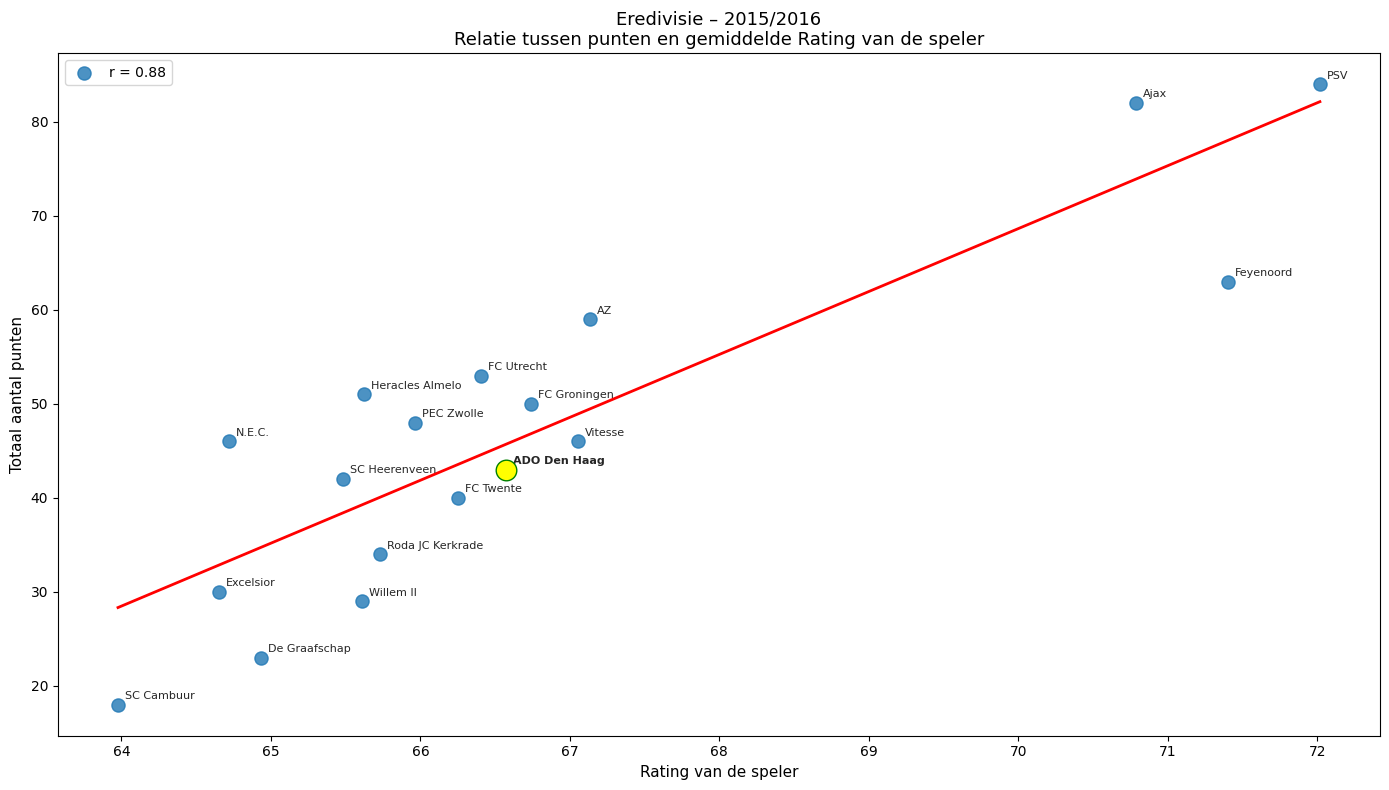

In [116]:
df_overall_rating_attribute = overall_rating.df_placement_plus_attribute

plot_points_vs_stat(
    df_combined=df_overall_rating_attribute[
        df_overall_rating_attribute["Season"] == "2015/2016"
    ],
    stat_col="overall_rating",
    stat_label="Rating van de speler",
    league_name="Eredivisie",
    season="2015/2016",
    team_name="ADO Den Haag",
    team_color="yellow",
    team_color_outline="green"
)

### Interpretatie

In deze grafiek is gekeken naar de relatie tussen de gemiddelde spelersrating van een team en het aantal behaalde punten in het seizoen 2015/2016 van de Eredivisie.

De correlatie van r = 0.88 laat zien dat er een sterke positieve relatie is. Dit betekent dat teams met betere spelers gemiddeld ook meer punten halen.

PSV en Ajax hebben bijvoorbeeld hoge spelersratings en staan ook hoog in punten. Teams zoals SC Cambuur en De Graafschap hebben lagere ratings en minder punten. Dit laat zien dat de kwaliteit van spelers veel invloed heeft op de prestaties van een team.

Er zijn ook uitzonderingen. Feyenoord heeft een redelijk hoge spelersrating, maar minder punten dan verwacht. Dit kan komen door andere factoren: zoals tactiek, blessures of samenwerking binnen het team.

### Statistiek 2 – short passing vs. Punten

Als tweede statistiek gebruiken we **short_passing** – de nauwkeurigheid van korte passes van spelers.
Teams waarvan de spelers korte passes goed uitvoeren, kunnen beter combineren en balbezit houden.
We onderzoeken of een hogere gemiddelde short passing score samenhangt met meer behaalde punten.


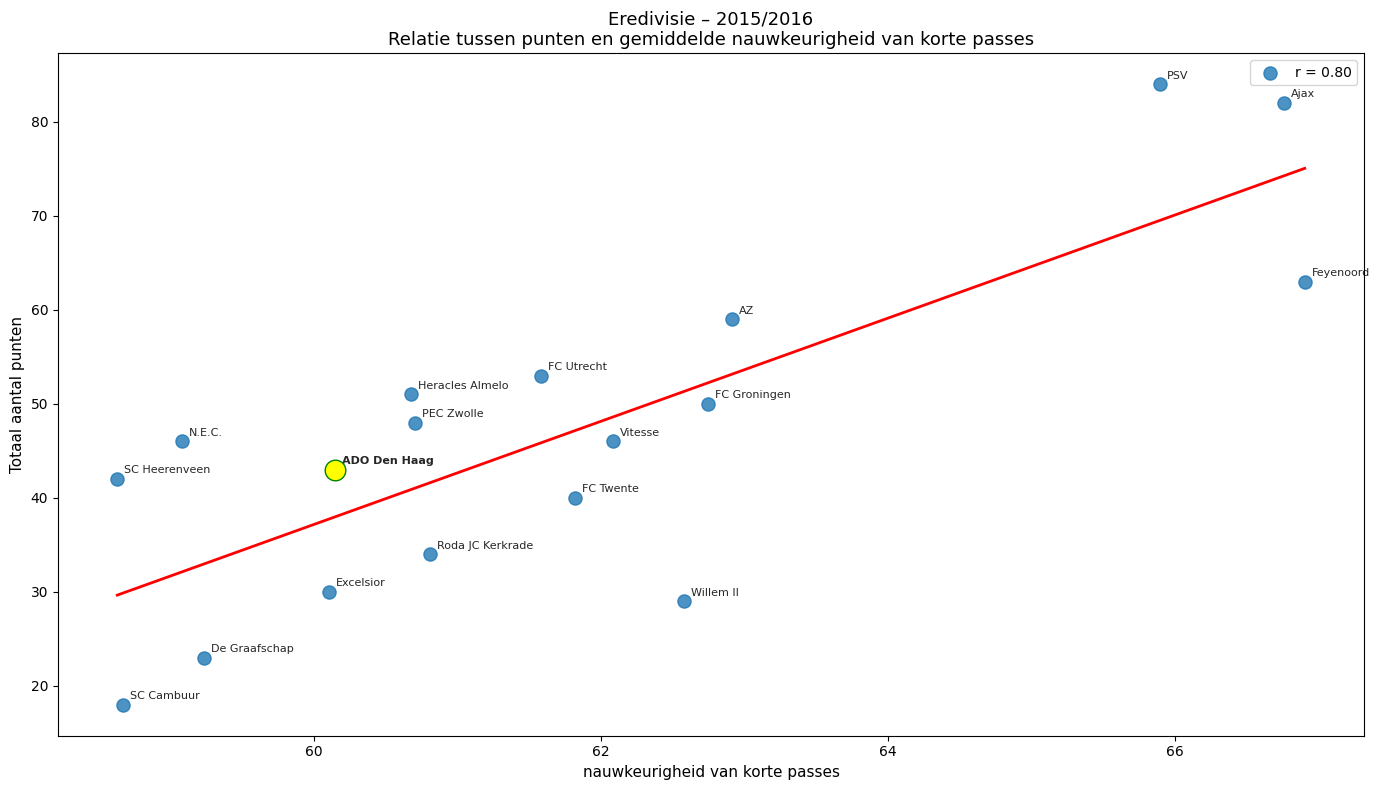

In [117]:
short_passing_points = short_passing.df_placement_plus_attribute
short_passing_points_2015 = short_passing_points[short_passing_points['Season'] == '2015/2016']


plot_points_vs_stat(
    df_combined= short_passing_points_2015,
    stat_col="short_passing",
    stat_label="nauwkeurigheid van korte passes",
    league_name="Eredivisie",
    season="2015/2016",
    team_name="ADO Den Haag",
    team_color="yellow",
    team_color_outline="green"
)



### Interpretatie

Deze grafiek laat zien dat teams die beter zijn in korte passes meestal ook meer punten behalen in de Eredivisie. De waarde van r = 0.80 laat zien dat er een duidelijke relatie is tussen passnauwkeurigheid en prestaties.

Teams zoals PSV en Ajax staan rechtsboven in de grafiek. Dit betekent dat zij veel punten halen en erg nauwkeurig zijn in korte passes. Teams zoals SC Cambuur en De Graafschap staan linksonder, wat laat zien dat zij minder nauwkeurig passen en ook minder punten behalen.

Er zijn ook uitzonderingen zichtbaar. Willem II heeft bijvoorbeeld een redelijk goede passnauwkeurigheid, maar behaalde toch weinig punten. Dit laat zien dat goede passing alleen niet genoeg is om succesvol te zijn.


### Conclusie voor de technisch directeur

- Investeer in spelerskwaliteit. De overall rating heeft de sterkste correlatie met punten (r = 0.88). Bij het aantrekken van nieuwe spelers is de overall rating een betrouwbare indicator voor verwachte prestatieverbetering.

- Let op passnauwkeurigheid bij transfers. Spelers met een hoge short passing score dragen bij aan balbezit en combinatiespel, wat samenhangt met meer punten (r = 0.80).

- Bouw voort op de huidige sterktes van ADO. Omdat ADO al overpresteerde ten opzichte van haar kader, is het belangrijk de tactische structuur en verbondenheid te behouden.

- Er zijn meerdere statistieken belangrijk. Zoals ook te zien in de heatmaps per seizoen hebben meerdere statistieken invloed op het puntentotaal. Overall rating en passing zijn sterke indicatoren, maar succes wordt bepaald door een combinatie van factoren.

# Sprint (5)

## Inhoud
- [1. Vorm en subvorm van machine learning](#1-vorm-en-subvorm-van-machine-learning)
- [2. De wedstrijdresultaten zijn toegevoegd aan Match_df](#2-de-wedstrijdresultaten-zijn-toegevoegd-aan-match_df)
- [6. Keuze van algoritmes](#2-keuze-van-algoritmes)
- [ 6.1 Logistic Regression](#61-logistic-regression)
- [6.2 K-Nearest Neighbors (KNN)](#62-k-nearest-neighbors-knn)
- [6.3 Waarom Random Forest en niet één Decision Tree?](#63-waarom-random-forest-en-niet-één-decision-tree)
- [6.4 Gradient Boosting](#64-gradient-boosting)
- [ Feature selection](#feature-selection-bij-onze-opdracht)
- [7. Voorspellen](#7-voorspellen)
- [7.1 Voorspellen-2-feature_selection](#71-voorspellen-2-feature_selection)
- [Avg-en-persoonsgegevens-thomas-levi-elyas](#opdracht-2--avg-en-persoonsgegevens-thomas-levi-elyas)
- [Ai-act-welke-categorie](#ai-act-welke-categorie)


### Doel van deze sprint

Het doel van deze sprint is om het resultaat van een voetbalwedstrijd te voorspellen met machine learning.

Er zijn drie mogelijkheden die wij willen voorspellen:

    ‘win’: het thuisteam wint
    ‘defeat’: het uitteam wint
    ‘draw’: de teams spelen gelijk


Daarvoor gebruiken wij spelerseigenschappenals input voor het model.

Deze sprint richt zich vooral op deze stappen:

- Het bepalen van de juiste vorm van machine learning.
- Het kiezen van geschikte features.
- Het voorbereiden en schalen van de data.
- Het trainen van minimaal twee machine learning modellen.
- Het vergelijken van de resultaten van deze modellen.

### 1. Vorm en subvorm van machine learning

Wij gebruiken **supervised learning**, omdat het model leert van data met een bekend antwoord.

De **features** zijn de gegevens die het model gebruikt, zoals spelerenschappen.  
De **target** is wat wij willen voorspellen: `win`, `defeat` of `draw`.

Het model leert dus de relatie tussen spelereigenschappen en het bekende wedstrijdresultaat. Daarom past supervised learning bij deze opdracht.

De subvorm is **supervised multi-class classification.** Het doel is namelijk niet om een continue waarde te voorspellen, maar een categorie. Omdat er drie mogelijke klassen zijn, gaat het specifieker om multiclass classification.

Volgens scikit-learn is multiclass classification een probleem waarbij er één targetvariabele is met meer dan twee mogelijke klassen. Dit past bij onze target `result`, omdat deze bestaat uit drie klassen: `win`, `defeat` en `draw`.  [Multiclass and multioutput algorithms](https://scikit-learn.org/stable/modules/multiclass.html)
 


### 2. De wedstrijdresultaten zijn toegevoegd aan Match_df

In [118]:
# Auteur: Thomas 
# Resultaten toegevoegd aan Match_df

Match_df_with_result = Match_df.copy()
def result_to_match(df, column1, column2):
    '''
    Voegt een kolom toe in Match_df_with_result waarin de uitkomst van de wedstrijd staat.
    De opties zijn: home_win, draw, away_win.
    
    '''
    Match_df_with_result["result"] = pd.Series([
        "home_win" if i > j else
        "draw" if i == j else
        "away_win"
        for i, j in zip(df[column1], df[column2])
    ])
    return Match_df_with_result



display(result_to_match(Match_df_with_result, "home_team_goal", "away_team_goal").head())



,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,home_player_X2,home_player_X3,home_player_X4,home_player_X5,home_player_X6,home_player_X7,home_player_X8,home_player_X9,home_player_X10,home_player_X11,away_player_X1,away_player_X2,away_player_X3,away_player_X4,away_player_X5,away_player_X6,away_player_X7,away_player_X8,away_player_X9,away_player_X10,away_player_X11,home_player_Y1,home_player_Y2,home_player_Y3,home_player_Y4,home_player_Y5,home_player_Y6,home_player_Y7,home_player_Y8,home_player_Y9,home_player_Y10,home_player_Y11,away_player_Y1,away_player_Y2,away_player_Y3,away_player_Y4,away_player_Y5,away_player_Y6,away_player_Y7,away_player_Y8,away_player_Y9,away_player_Y10,away_player_Y11,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,goal,shoton,shotoff,foulcommit,card,cross,corner,possession,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,LBH,LBD,LBA,PSH,PSD,PSA,WHH,WHD,WHA,SJH,SJD,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA,result
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.73,3.40,5.00,1.75,3.35,4.20,1.85,3.2,3.5,1.80,3.3,3.75,NaN,NaN,NaN,1.70,3.30,4.33,1.90,3.3,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20,draw
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.95,3.20,3.60,1.80,3.30,3.95,1.90,3.2,3.5,1.90,3.2,3.50,NaN,NaN,NaN,1.83,3.30,3.60,1.95,3.3,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60,draw
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.38,3.30,2.75,2.40,3.30,2.55,2.60,3.1,2.3,2.50,3.2,2.50,NaN,NaN,NaN,2.50,3.25,2.40,2.63,3.3,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75,away_win
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.44,3.75,7.50,1.40,4.00,6.80,1.40,3.9,6.0,1.44,3.6,6.50,NaN,NaN,NaN,1.44,3.75,6.00,1.44,4.0,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50,home_win
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,3.50,1.65,5.00,3.50,1.60,4.00,3.3,1.7,4.00,3.4,1.72,NaN,NaN,NaN,4.20,3.40,1.70,4.50,3.5,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67,away_win


## 3. Features selecteren

In [119]:
# Auteur: Roan van Dam

def calculate_correlation_w_result(match_df, df_player_avg, attributes):
    """
    berekent de correlatie tussen gemiddelde speler attribuut van een team en het winnen,
    gelijk spelen of verliezen van het home team. Deze correlaties worden teruggestuurd voor verder gebruik.

    PARAMETERS:
        - match_df (Pandas.DataFrame):
            dataframe met alle nodige informatie over de match, zoals teams en resultaat.
        - df_player_avg (Pandas.DataFrame):
            gemiddelde speler attribuut per seizoen van een speler.
        - attributes (list):
            lijst van alle namen van de relevante speler attributen.
    
    RETURNS:
        - correlation_results (dict):
            dictionary met speler attribuut als key en correlatie met result als waarde 
    """
    
    # Zorg er eerst voor dat de win omgezet wordt naar cijfers
    home_points_map = {'home_win': 2, 'draw': 1, 'away_win': 0}
    away_points_map = {'home_win': 0, 'draw': 1, 'away_win': 2}
    
    home_pts = match_df['result'].map(home_points_map).values
    away_pts = match_df['result'].map(away_points_map).values

    # Home en away team mergen met elkaar
    total_points = np.concatenate([home_pts, away_pts])
    
    # Speler namen 1 t/m 11 aanmaken in een lisjt 
    home_cols = [f"home_player_{i}" for i in range(1, 12)]
    away_cols = [f"away_player_{i}" for i in range(1, 12)]
    
    home_players = match_df[home_cols].values  # Shape: (Matches, 11)
    away_players = match_df[away_cols].values  # Shape: (Matches, 11)

    
    # Maak een nieuwe numpy array met max_id + 1 als aantal rijen
    # En het aantal speler attributen als aantal kolommen.
    # Vul de gehele nieuwe array met np.nan 
    max_id = int(df_player_avg['player_api_id'].max())
    lookup_matrix = np.full((max_id + 1, len(attributes)), np.nan)
    
    # Vul de eerdere matrix met rijen = player_api_id en kolommen = attribuut waarde
    player_ids = df_player_avg['player_api_id'].values.astype(int)
    for idx, attr in enumerate(attributes):
        lookup_matrix[player_ids, idx] = df_player_avg[attr].values

    # Pas alle Null waardes aan naar 0
    home_attr_weights = lookup_matrix[np.where(np.isnan(home_players), 0, home_players).astype(int)]
    away_attr_weights = lookup_matrix[np.where(np.isnan(away_players), 0, away_players).astype(int)]
    
    # Deze stuk code maakt id's die niet bekend zijn irrelevant.
    home_attr_weights[np.isnan(home_players)] = np.nan
    away_attr_weights[np.isnan(away_players)] = np.nan
    
    # Maak de algemene speler attribuut waarde gemiddeld per match.
    home_means = np.nanmean(home_attr_weights, axis=1)
    away_means = np.nanmean(away_attr_weights, axis=1)
    
    # Merge de home en away team arrays
    total_attributes = np.vstack([home_means, away_means])
    
    
    correlation_results = {}
    
    # Deze for loop berekent de correlatie met result.
    for idx, attr in enumerate(attributes):
        attr_vector = total_attributes[:, idx]
        
        # Ervoor zorgen dat er geen Null waardes voorkomen
        valid_mask = ~np.isnan(attr_vector) & ~np.isnan(total_points)
        clean_attr = attr_vector[valid_mask]
        clean_pts = total_points[valid_mask]
        
        # Bereken de correlatie met resultaat en en stuurt deze door naar de correlation_results
        if len(clean_attr) >= 2:
            corr = np.corrcoef(clean_attr, clean_pts)[0, 1]
            correlation_results[attr] = corr
        else:
            correlation_results[attr] = 0.0
            
    return correlation_results


player_attributes = [
    "overall_rating", "crossing", "finishing", "heading_accuracy", "short_passing",
    "volleys", "dribbling", "ball_control", "acceleration", "sprint_speed",
    "agility", "reactions", "balance", "shot_power", "jumping", "stamina",
    "interceptions", "positioning", "vision", "marking", "standing_tackle",
    "sliding_tackle", "gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes"
]

correlations_dict = calculate_correlation_w_result(Match_df_with_result, df_player_avg, player_attributes)

# Sorteert o.b.v. hoog tot lage correlatie
sorted_correlations = sorted(correlations_dict.items(), key=lambda item: item[1], reverse=True)

# Print the top 10 highest correlations
print("Top 10 speler attributen correlerend met match resultaat:")
print("-" * 65)
for rank, (attr, corr) in enumerate(sorted_correlations[:10], 1):
    print(f"{rank}. {attr.ljust(25)} Correlatie: {corr:.4f}")
print("-" * 65)

Top 10 speler attributen correlerend met match resultaat:
-----------------------------------------------------------------
1. dribbling                 Correlatie: 0.1898
2. finishing                 Correlatie: 0.1756
3. ball_control              Correlatie: 0.1747
4. short_passing             Correlatie: 0.1731
5. overall_rating            Correlatie: 0.1730
6. vision                    Correlatie: 0.1696
7. positioning               Correlatie: 0.1658
8. reactions                 Correlatie: 0.1634
9. volleys                   Correlatie: 0.1595
10. crossing                  Correlatie: 0.1587
-----------------------------------------------------------------


C:\Users\adels\AppData\Local\Temp\ipykernel_21576\767751864.py:59: RuntimeWarning: Mean of empty slice
  home_means = np.nanmean(home_attr_weights, axis=1)
C:\Users\adels\AppData\Local\Temp\ipykernel_21576\767751864.py:60: RuntimeWarning: Mean of empty slice
  away_means = np.nanmean(away_attr_weights, axis=1)


### Uitleg gekozen features

Wij hadden een code geschreven die correlaties kan berekenen tussen de speler attributen en het resultaat van een match. Deze lijst konden we goed gebruiken om het systeem te tunen om de resultaten nog beter te maken. Deze correlaties waren berekent waaruit de volgende top 10 was ontstaan:

    dribbling Correlatie: 0.1898
    finishing Correlatie: 0.1756
    ball control Correlatie: 0.1747
    short passing Correlatie: 0.1731
    overall rating Correlatie: 0.1730
    vision Correlatie: 0.1696
    positioning Correlatie: 0.1658
    reactions Correlatie: 0.1634
    volleys Correlatie: 0.1595
    crossing Correlatie: 0.1587


## 4. Het verschil berkenen van Home-away time

In [120]:
# Auteur: Levi

class MatchPreprocessing:
    """
    Maakt een nieuw dataframe met alleen:
    - het resultaat per wedstrijd
    - de gekozen features per wedstrijd
    """

    def __init__(self, match_df_with_result, df_player_avg, conn, league_name=None):
        """
        Parameters:
        - match_df_with_result: match dataframe met kolom 'result'
        - df_player_avg: dataframe uit opdracht 1a
        - conn: database connectie
        - league_name: naam van de competitie, bijvoorbeeld 'Netherlands Eredivisie'
        """
        self.match_df_with_result = match_df_with_result.copy()
        self.df_player_avg = df_player_avg.copy()
        self.conn = conn
        self.league_name = league_name

        # Features uit de screenshot
        self.selected_features = [
            "dribbling",
            "finishing",
            "ball_control",
            "short_passing",
            "overall_rating",
            "vision",
            "positioning",
            "reactions",
            "volleys",
            "crossing"
        ]

    def select_league(self):
        """
        Filtert het match dataframe op basis van de gekozen league.
        Als er geen league_name is opgegeven, wordt het hele dataframe gebruikt.
        """
        if self.league_name is None:
            return self.match_df_with_result

        query = """
        SELECT id
        FROM League
        WHERE name = ?
        """

        league_df = pd.read_sql(query, self.conn, params=[self.league_name])

        if league_df.empty:
            raise ValueError(f"League '{self.league_name}' bestaat niet.")

        league_id = league_df.iloc[0]["id"]

        filtered_df = self.match_df_with_result[
            self.match_df_with_result["league_id"] == league_id
        ].copy()

        return filtered_df

    def build_match_feature_df(self):
        """
        Maakt per wedstrijd de gekozen features op basis van
        het gemiddelde van de spelers van thuis en uit.
        """
        rows = []

        # Eerst de juiste league selecteren
        match_df = self.select_league()

        for _, row in match_df.iterrows():
            match_row = {
                "match_api_id": row["match_api_id"],
                "result": row["result"]
            }

            # Thuisspelers verzamelen
            home_ids = [
                row[f"home_player_{i}"]
                for i in range(1, 12)
                if pd.notna(row[f"home_player_{i}"])
            ]

            # Uitspelers verzamelen
            away_ids = [
                row[f"away_player_{i}"]
                for i in range(1, 12)
                if pd.notna(row[f"away_player_{i}"])
            ]

            # Spelerdata opzoeken in df_player_avg
            home_stats = self.df_player_avg[
                self.df_player_avg["player_api_id"].isin(home_ids)
            ]

            away_stats = self.df_player_avg[
                self.df_player_avg["player_api_id"].isin(away_ids)
            ]

            # Gemiddelde per feature berekenen
            for feature in self.selected_features:
                home_mean = home_stats[feature].mean()
                away_mean = away_stats[feature].mean()

                # Alleen difference feature bewaren
                match_row[f"{feature}_diff"] = home_mean - away_mean

            rows.append(match_row)

        final_df = pd.DataFrame(rows)
        return final_df

    def fill_missing_values(self, df):
        """
        Vult missende waarden op met de mediaan van de kolom.
        """
        df = df.copy()
        num_cols = df.select_dtypes(include=["number"]).columns
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())
        return df

    def transform(self):
        """
        Voert alle preprocessing stappen uit.
        """
        final_df = self.build_match_feature_df()
        final_df = self.fill_missing_values(final_df)
        return final_df

In [121]:
preprocessor = MatchPreprocessing(
    match_df_with_result=Match_df_with_result,
    df_player_avg=df_player_avg,
    conn=conn,
    league_name="Netherlands Eredivisie"
)

final_match_df = preprocessor.transform()

display(final_match_df.head())
print(final_match_df.shape)

,match_api_id,result,dribbling_diff,finishing_diff,ball_control_diff,short_passing_diff,overall_rating_diff,vision_diff,positioning_diff,reactions_diff,volleys_diff,crossing_diff
0,508287,away_win,-2.044090,-5.809307,-2.345995,-3.267400,-0.229346,-7.121457,-7.753999,-1.305686,-9.306208,-4.554166
1,508303,draw,-4.460627,-2.538405,-1.506941,0.342824,-3.615741,-0.934954,-3.293357,-1.321776,-3.114042,0.931821
2,508304,home_win,-13.056741,-10.947579,-12.321273,-11.982385,-10.567377,-6.250406,-6.035985,-11.554858,-16.276150,-13.663479
3,508305,home_win,-2.129361,1.029191,-0.970505,2.080668,4.368273,4.859940,-4.833477,4.565508,-2.412404,-0.547070
4,508306,away_win,-11.099399,-5.182872,-12.021261,-9.775818,-4.982224,-13.694761,-8.635962,-4.295871,-10.260894,-9.790415


(2448, 12)


### 6. Keuze van algoritmes

Voor deze opdracht gebruiken wij modellen die geschikt zijn voor **multi-class classification**.
Wij kunnen meerdere modellen testen en daarna vergelijken welk model het beste werkt. DEZE UITWERKING IS GEMAAKT MET BEHULP VAN GEN-AI [LINK](https://chatgpt.com/share/6a0ee011-f668-83eb-8a1f-4c7e7623e9eb)

#### 6.1 Logistic Regression

Logistic Regression berekent per wedstrijd een kans voor elke klasse.  
Daarna kiest het model de klasse met de hoogste kans als voorspelling.

Bijvoorbeeld:

- `win`: 60%
- `draw`: 25%
- `defeat`: 15%

De voorspelling wordt dan `win`, omdat deze klasse de hoogste kans heeft.

De **multinomial case** betekent dat Logistic Regression niet alleen tussen twee keuzes kiest, maar tussen meerdere categorieën.  
In onze opdracht zijn dat `win`, `defeat` en `draw`. [Multinomial Case](https://scikit-learn.org/stable/modules/linear_model.html#multinomial-case)

Daarom past Logistic Regression bij onze analyse.



#### 6.2 K-Nearest Neighbors (KNN)

KNN past goed bij onze opdracht, omdat wij historische wedstrijden hebben waarvan het resultaat al bekend is.

Het model vergelijkt een nieuwe wedstrijd met wedstrijden uit het verleden die er het meest op lijken.  
Daarna kijkt KNN welke klasse het vaakst voorkomt bij deze dichtstbijzijnde wedstrijden.


Als de meeste vergelijkbare wedstrijden eindigden in een thuiswinst, voorspelt KNN `win`.  
Als de meeste eindigden in een uitwinst, voorspelt KNN `defeat`.  
Als de meeste eindigden in een gelijkspel, voorspelt KNN `draw`.

KNN kan dus ook gebruikt worden voor **multi-class classification**.

Wel moeten wij de features eerst schalen, omdat KNN werkt met afstanden. Zonder schalen kunnen features met grote waarden te veel invloed krijgen op de voorspelling.
 

#### 6.3 Waarom Random Forest en niet één Decision Tree?

Wij gebruiken `Random Forest`, omdat dit model meerdere decision trees samen gebruikt.  
Dit is vaak beter dan één losse decision tree. [Random Forests](https://scikit-learn.org/stable/modules/ensemble.html#random-forests)

Een losse decision tree kan snel **overfitten**.  
Dat betekent dat het model de trainingsdata te goed leert, maar minder goed werkt op nieuwe wedstrijden.

Random Forest verkleint dit probleem door meerdere bomen te maken.  
Elke boom wordt getraind op een willekeurig deel van de trainingsdata. Dit heet een **bootstrap sample**. [Parameters Random Forests](https://scikit-learn.org/stable/modules/ensemble.html#parameters)

Daarnaast kiest Random Forest bij elke boom ook willekeurig een deel van de features.  
Daardoor worden de bomen verschillend van elkaar.

Daarna combineert het model de voorspellingen van alle bomen.  
Hierdoor wordt de voorspelling vaak stabieler dan bij één decision tree.

Voor onze opdracht is Random Forest geschikt, omdat wij een multi-class classification probleem hebben met drie mogelijke uitkomsten: `win`, `defeat` en `draw`.

#### 6.4 Gradient Boosting

Gradient Boosting past goed bij onze opdracht, omdat het model meerdere decision trees gebruikt.

Het model bouwt de trees stap voor stap.  
Elke nieuwe tree probeert de fouten van de vorige trees te verbeteren.

Dit werkt ongeveer zo:

1. Het eerste model maakt voorspellingen.
2. Het model kijkt welke voorspellingen fout zijn.
3. Een nieuwe tree probeert deze fouten te verbeteren.
4. Deze tree wordt toegevoegd aan het model.
5. Dit proces wordt meerdere keren herhaald.

Het verschil met Random Forest is dat Random Forest veel bomen los van elkaar maakt.  
Gradient Boosting maakt de bomen juist stap voor stap.

Gradient Boosting kan gebruikt worden voor:

- regression
- classification


Scikit-learn geeft aan dat Gradient Boosted Decision Trees goed kunnen werken bij **tabulaire data**.  
Tabulaire data betekent data in tabelvorm, met rijen en kolommen.[ Gradient-boosted trees](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosted-trees)

Dat past bij onze dataset, omdat wij werken met kolommen zoals spelersratings en wedstrijdgegevens.


### Feature selection 

Feature selection is belangrijk in deze opdracht, omdat wij veel spelerseigenschappen kunnen gebruiken. 
Niet alle spelerseigenschappen hebben waarschijnlijk veel invloed op het voorspellen van `win`, `defeat` en `draw`.

Een eenvoudige methode is `VarianceThreshold`. Deze methode verwijdert features met weinig variatie. 
Als een feature bijna altijd dezelfde waarde heeft, geeft deze feature waarschijnlijk weinig informatie aan het model. [Removing features with low variance](https://scikit-learn.org/stable/modules/feature_selection.html#removing-features-with-low-variance)

Wel is `VarianceThreshold` beperkt, omdat deze methode alleen naar de features kijkt en niet naar de target. 
Daarom voorspelt feature selection zelf geen wedstrijdresultaat. 
Het is een preprocessing-stap die andere modellen kan helpen beter of sneller te werken. [Feature selection as part of a pipeline](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection-as-part-of-a-pipeline)

## 7. VOORSPELLEN

c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,accuracy_score,best_params
0,Logistic Regression,0.559758,"{'model__C': 0.01, 'model__penalty': 'l2', 'sc..."
2,Random Forest,0.553115,"{'model__max_depth': 5, 'model__min_samples_le..."
3,Gradient Boosting,0.552094,"{'model__learning_rate': 0.05, 'model__max_dep..."
1,KNN,0.502021,"{'model__metric': 'euclidean', 'model__n_neigh..."


c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,f1_macro_score,best_params
2,Random Forest,0.424034,"{'model__max_depth': None, 'model__min_samples..."
1,KNN,0.423015,"{'model__metric': 'manhattan', 'model__n_neigh..."
3,Gradient Boosting,0.418927,"{'model__learning_rate': 0.05, 'model__max_dep..."
0,Logistic Regression,0.402151,"{'model__C': 0.01, 'model__penalty': 'l2', 'sc..."


Beste model op accuracy: Logistic Regression
Beste parameters: {'model__C': 0.01, 'model__penalty': 'l2', 'scaler': StandardScaler()}

Beste model op f1_macro: Random Forest
Beste parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'scaler': StandardScaler()}


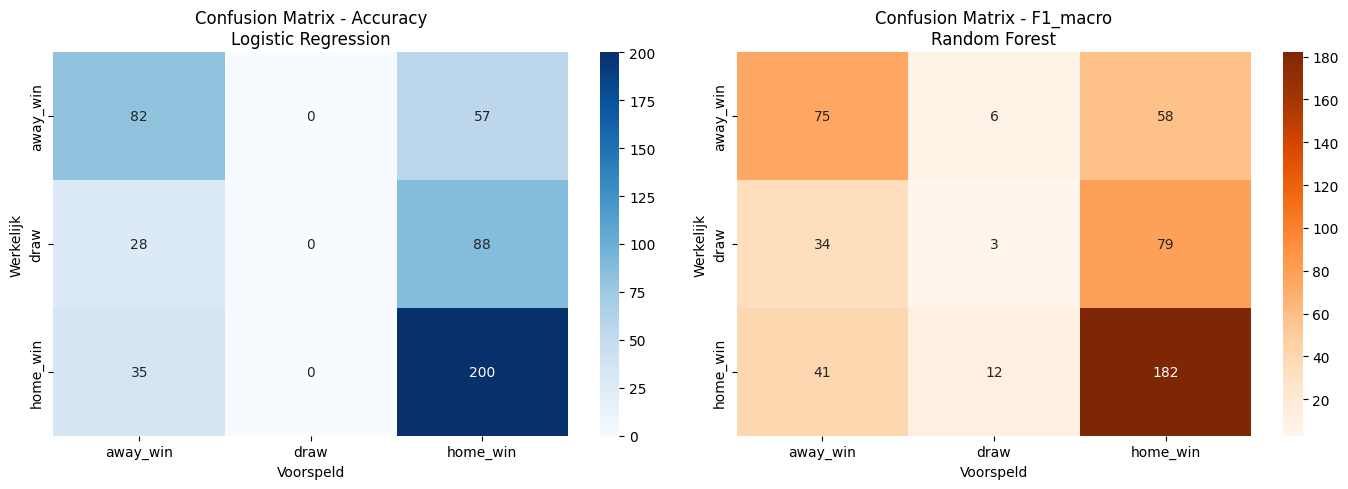

Test accuracy van accuracy-model: 0.5755102040816327
Test accuracy van f1_macro-model: 0.5306122448979592

Classification report - accuracy model
              precision    recall  f1-score   support

    away_win       0.57      0.59      0.58       139
        draw       0.00      0.00      0.00       116
    home_win       0.58      0.85      0.69       235

    accuracy                           0.58       490
   macro avg       0.38      0.48      0.42       490
weighted avg       0.44      0.58      0.49       490


Classification report - f1_macro model
              precision    recall  f1-score   support

    away_win       0.50      0.54      0.52       139
        draw       0.14      0.03      0.04       116
    home_win       0.57      0.77      0.66       235

    accuracy                           0.53       490
   macro avg       0.40      0.45      0.41       490
weighted avg       0.45      0.53      0.47       490



c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
# Auteur: Adel 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------
# 1. Data klaarzetten
# -------------------------
X = final_match_df.drop(columns=["result", "match_api_id"], errors="ignore")
y = final_match_df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# 2. Pipelines
# -------------------------
pipeline_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    ))
])

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline_gb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(random_state=42))
])

# -------------------------
# 3. Parameter grids
# -------------------------
param_grid_logreg = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"]
}

param_grid_knn = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

param_grid_rf = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

param_grid_gb = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

models = {
    "Logistic Regression": (pipeline_logreg, param_grid_logreg),
    "KNN": (pipeline_knn, param_grid_knn),
    "Random Forest": (pipeline_rf, param_grid_rf),
    "Gradient Boosting": (pipeline_gb, param_grid_gb)
}

# -------------------------
# 4. GridSearchCV voor accuracy
# -------------------------
results_accuracy = []
best_models_accuracy = {}

for name, (pipe, param_grid) in models.items():
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_models_accuracy[name] = grid.best_estimator_

    results_accuracy.append({
        "model": name,
        "accuracy_score": grid.best_score_,
        "best_params": grid.best_params_
    })

results_df_accuracy = pd.DataFrame(results_accuracy).sort_values(
    by="accuracy_score",
    ascending=False
)

display(results_df_accuracy)

# -------------------------
# 5. GridSearchCV voor f1_macro
# -------------------------
results_f1 = []
best_models_f1 = {}

for name, (pipe, param_grid) in models.items():
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_models_f1[name] = grid.best_estimator_

    results_f1.append({
        "model": name,
        "f1_macro_score": grid.best_score_,
        "best_params": grid.best_params_
    })

results_df_f1 = pd.DataFrame(results_f1).sort_values(
    by="f1_macro_score",
    ascending=False
)

display(results_df_f1)

# -------------------------
# 6. Beste model per metric kiezen
# -------------------------
best_model_name_accuracy = results_df_accuracy.iloc[0]["model"]
best_model_accuracy = best_models_accuracy[best_model_name_accuracy]

best_model_name_f1 = results_df_f1.iloc[0]["model"]
best_model_f1 = best_models_f1[best_model_name_f1]

print("Beste model op accuracy:", best_model_name_accuracy)
print("Beste parameters:", results_df_accuracy.iloc[0]["best_params"])
print()

print("Beste model op f1_macro:", best_model_name_f1)
print("Beste parameters:", results_df_f1.iloc[0]["best_params"])

# -------------------------
# 7. Voorspellingen maken
# -------------------------
y_pred_accuracy = best_model_accuracy.predict(X_test)
y_pred_f1 = best_model_f1.predict(X_test)

# Zelfde volgorde van labels gebruiken
labels_order = sorted(y_test.unique())

# -------------------------
# 8. Confusion matrices maken
# -------------------------
cm_accuracy = confusion_matrix(y_test, y_pred_accuracy, labels=labels_order)
cm_f1 = confusion_matrix(y_test, y_pred_f1, labels=labels_order)

# -------------------------
# 9. Twee heatmaps tekenen
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_accuracy,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_order,
    yticklabels=labels_order,
    ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix - Accuracy\n{best_model_name_accuracy}")
axes[0].set_xlabel("Voorspeld")
axes[0].set_ylabel("Werkelijk")

sns.heatmap(
    cm_f1,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=labels_order,
    yticklabels=labels_order,
    ax=axes[1]
)
axes[1].set_title(f"Confusion Matrix - F1_macro\n{best_model_name_f1}")
axes[1].set_xlabel("Voorspeld")
axes[1].set_ylabel("Werkelijk")

plt.tight_layout()
plt.show()

# -------------------------
# 10. Extra scores printen
# -------------------------
print("Test accuracy van accuracy-model:", accuracy_score(y_test, y_pred_accuracy))
print("Test accuracy van f1_macro-model:", accuracy_score(y_test, y_pred_f1))

print("\nClassification report - accuracy model")
print(classification_report(y_test, y_pred_accuracy))

print("\nClassification report - f1_macro model")
print(classification_report(y_test, y_pred_f1))

### Confusion matrix uitleg en modelvergelijking (Thomas en Adel)

In onze vergelijking hebben wij gekeken naar twee manieren om het beste model te kiezen: **accuracy** en **F1-macro**.

Als wij alleen naar **accuracy** kijken, is **Logistic Regression** het beste model. Dit model heeft een test accuracy van ongeveer **57.6%**. Maar de confusion matrix laat een probleem zien: het model voorspelt geen enkele **draw** goed. Van de **116 draws** zijn er **0 correct voorspeld**. Dit betekent dat het model de klasse **draw** eigenlijk negeert.

Bij Logistic Regression zijn de resultaten:

- **away_win**: 82 van de 139 correct voorspeld
- **draw**: 0 van de 116 correct voorspeld
- **home_win**: 200 van de 235 correct voorspeld

Daarom geeft accuracy hier een te positief beeld. Het model lijkt goed, maar het voorspelt niet alle klassen goed.

Als wij kijken naar **F1-macro**, komt **Random Forest** als beste model uit de cross-validation. F1-macro is beter voor deze opdracht, omdat elke klasse even zwaar meetelt. Dus **draw** telt evenveel mee als **home_win** en **away_win** (Scikit-learn developers, z.d.-b).

Bij Random Forest zijn de resultaten:

- **away_win**: 75 van de 139 correct voorspeld
- **draw**: 3 van de 116 correct voorspeld
- **home_win**: 182 van de 235 correct voorspeld

Random Forest voorspelt **draw** nog steeds slecht, maar het model wordt gekozen omdat het in de vergelijking met **F1-macro** het beste scoort. Het verschil met KNN is wel klein. Daarom kunnen wij niet zeggen dat Random Forest veel beter is dan KNN.

Een belangrijk punt is dat wij het model niet alleen moeten vergelijken met willekeurig gokken van **33.3%**. De klassen zijn namelijk niet even groot. Een simpel model dat altijd **home_win** voorspelt, zou al ongeveer **48% accuracy** halen. Ons beste accuracy-model is dus beter dan zo’n simpel model, maar niet extreem veel beter.

De conclusie is dat **Logistic Regression beter lijkt als wij alleen naar accuracy kijken**, maar dit model mist de klasse **draw** volledig. Daarom is **F1-macro eerlijker** voor deze opdracht. Binnen deze vergelijking kiezen wij daarom voor **Random Forest**, maar het model is nog niet sterk genoeg om zonder menselijke controle te gebruiken.

### Bronnen

Scikit-learn developers. (z.d.-a). *Accuracy_score*. Scikit-learn documentation.  
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

Scikit-learn developers. (z.d.-b). *F1_score*. Scikit-learn documentation.  
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

### Toelichting gebruikte metrics

Voor het kiezen en beoordelen van de modellen zijn meerdere metrics gebruikt:

- **F1-macro**  
  Deze metric is gebruikt in de gridsearch.  
  Hij berekent de F1-score voor elke klasse apart en neemt daarna het gemiddelde.  
  Dit is handig, omdat we drie klassen hebben: `home_win`, `draw` en `away_win`.

- **Accuracy**  
  Accuracy laat zien welk deel van alle voorspellingen correct is.  
  Als de accuracy 0.60 is, betekent dit dat 60% van de wedstrijden goed is voorspeld.

- **Precision**  
  Precision laat zien hoe vaak een voorspelde klasse echt correct is.  
  Bijvoorbeeld: van alle keren dat het model `home_win` voorspelt, hoe vaak klopt dat?

- **Recall**  
  Recall laat zien hoeveel van de echte gevallen het model goed terugvindt.  
  Bijvoorbeeld: van alle echte `draw` wedstrijden, hoeveel heeft het model goed gevonden?

- **F1-score**  
  De F1-score is een combinatie van precision en recall.  
  Deze metric is handig als je een balans wilt tussen beide.

- **Support**  
  Support laat zien hoeveel echte voorbeelden er van elke klasse in de testset zijn.

- **Confusion matrix**  
  De confusion matrix laat zien welke klassen goed en fout zijn voorspeld.  
  Zo kun je bijvoorbeeld zien of het model een `draw` vaak verwart met `home_win`.

## 7.1 Voorspellen (2) feature_selection

In [123]:
from sklearn.feature_selection import SelectKBest, f_classif

def result_to_match(df, column1="home_team_goal", column2="away_team_goal"):
    """
    Voegt een kolom 'result' toe aan het match dataframe.
    """
    df = df.copy()

    df["result"] = [
        "home_win" if i > j else
        "draw" if i == j else
        "away_win"
        for i, j in zip(df[column1], df[column2])
    ]

    return df

Match_df_with_result = result_to_match(Match_df)


class MatchPlayerAttributesAnalysis:
    """
    Bouwt een match-level dataframe op basis van gemiddelde spelerattributen.
    Eén rij = één wedstrijd.
    """

    def __init__(self, conn, df_player_avg, attributes):
        self.conn = conn
        self.df_player_avg = df_player_avg.copy()
        self.attributes = attributes

    def get_match_df(self):
        """
        Haalt alleen Eredivisie wedstrijden op.
        """
        query = """
        SELECT
            m.id,
            m.country_id,
            m.league_id,
            m.season,
            m.stage,
            m.date,
            m.match_api_id,
            m.home_team_api_id,
            m.away_team_api_id,
            m.home_team_goal,
            m.away_team_goal,
            m.home_player_1, m.home_player_2, m.home_player_3,
            m.home_player_4, m.home_player_5, m.home_player_6,
            m.home_player_7, m.home_player_8, m.home_player_9,
            m.home_player_10, m.home_player_11,
            m.away_player_1, m.away_player_2, m.away_player_3,
            m.away_player_4, m.away_player_5, m.away_player_6,
            m.away_player_7, m.away_player_8, m.away_player_9,
            m.away_player_10, m.away_player_11
        FROM Match m
        JOIN League l
            ON m.league_id = l.id
        WHERE l.name = 'Netherlands Eredivisie'
        """
        return pd.read_sql(query, self.conn)

    def build_match_features(self):
        """
        Maakt per wedstrijd de gemiddelde player attributes van home en away,
        en ook het verschil tussen beide teams.
        """
        match_df = self.get_match_df()
        match_df = result_to_match(match_df)

        rows = []

        for _, row in match_df.iterrows():
            match_row = {
                "match_api_id": row["match_api_id"],
                "season": row["season"],
                "date": row["date"],
                "result": row["result"]
            }

            home_ids = [row[f"home_player_{i}"] for i in range(1, 12) if pd.notna(row[f"home_player_{i}"])]
            away_ids = [row[f"away_player_{i}"] for i in range(1, 12) if pd.notna(row[f"away_player_{i}"])]

            home_stats = self.df_player_avg[self.df_player_avg["player_api_id"].isin(home_ids)]
            away_stats = self.df_player_avg[self.df_player_avg["player_api_id"].isin(away_ids)]

            for attr in self.attributes:
                home_mean = home_stats[attr].mean()
                away_mean = away_stats[attr].mean()

                match_row[f"home_avg_{attr}"] = home_mean
                match_row[f"away_avg_{attr}"] = away_mean
                match_row[f"{attr}_diff"] = home_mean - away_mean

            rows.append(match_row)

        final_df = pd.DataFrame(rows)

        numeric_cols = final_df.select_dtypes(include=["number"]).columns.tolist()
        if "match_api_id" in numeric_cols:
            numeric_cols.remove("match_api_id")

        final_df[numeric_cols] = final_df[numeric_cols].fillna(final_df[numeric_cols].median())

        return final_df
    
    
player_attributes = [
    "overall_rating",
    "crossing",
    "finishing",
    "heading_accuracy",
    "short_passing",
    "volleys",
    "dribbling",
    "ball_control",
    "acceleration",
    "sprint_speed",
    "agility",
    "reactions",
    "balance",
    "shot_power",
    "jumping",
    "stamina",
    "interceptions",
    "positioning",
    "vision",
    "marking",
    "standing_tackle",
    "sliding_tackle",
    "gk_diving",
    "gk_handling",
    "gk_kicking",
    "gk_positioning",
    "gk_reflexes"
]    



match_builder = MatchPlayerAttributesAnalysis(
    conn=conn,
    df_player_avg=df_player_avg,
    attributes=player_attributes
)

match_features_df = match_builder.build_match_features()



X = match_features_df.drop(columns=["result", "match_api_id", "season", "date"], errors="ignore")
y = match_features_df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()].tolist()
print("Geselecteerde features:", selected_features)

final_match_df = match_features_df[["result"] + selected_features].copy()

display(final_match_df.head())
print(final_match_df.shape)


Geselecteerde features: ['home_avg_overall_rating', 'overall_rating_diff', 'crossing_diff', 'short_passing_diff', 'dribbling_diff', 'ball_control_diff', 'reactions_diff', 'shot_power_diff', 'positioning_diff', 'vision_diff']


,result,home_avg_overall_rating,overall_rating_diff,crossing_diff,short_passing_diff,dribbling_diff,ball_control_diff,reactions_diff,shot_power_diff,positioning_diff,vision_diff
0,away_win,68.867895,-0.229346,-4.554166,-3.267400,-2.044090,-2.345995,-1.305686,-9.861977,-7.753999,-7.121457
1,draw,67.415917,-3.615741,0.931821,0.342824,-4.460627,-1.506941,-1.321776,0.566091,-3.293357,-0.934954
2,home_win,65.508509,-10.567377,-13.663479,-11.982385,-13.056741,-12.321273,-11.554858,-20.022591,-6.035985,-6.250406
3,home_win,67.750416,4.368273,-0.547070,2.080668,-2.129361,-0.970505,4.565508,6.119579,-4.833477,4.859940
4,away_win,67.388311,-4.982224,-9.790415,-9.775818,-11.099399,-12.021261,-4.295871,-13.922346,-8.635962,-13.694761


(2448, 11)


### Waarop baseert `SelectKBest` de selectie?

`SelectKBest` gebruikt geen coefficients en traint ook geen echt machine learning model. Met `f_classif` gebruikt hij een ANOVA F-test. Deze test kijkt naar elke feature apart en geeft elke feature een score. Die score laat zien hoe sterk een feature verschilt tussen de klassen in `y_train`. Een hogere score betekent dat de feature volgens deze test belangrijker is. Met `k=10` kiest `SelectKBest` alleen de 10 features met de hoogste scores. Dus de selectie is gebaseerd op statistische scores, niet op model-coefficients. Let op: hij kijkt niet naar combinaties van features, maar alleen naar elke feature apart.

Bronnen: [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html) en [f_classif](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html).

1. Check correlatie tussen features
2. Verwijder één feature uit paren met heel hoge correlatie, bijvoorbeeld > 0.85 of > 0.90
3. Gebruik daarna SelectKBest in een Pipeline
4. Test met GridSearchCV welke k het beste werkt

Training: Logistic Regression


c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Training: KNN
Training: Random Forest
Training: Gradient Boosting


,model,best_cv_score,best_params
0,Logistic Regression,0.559758,"{'model__C': 0.01, 'model__penalty': 'l2', 'pr..."
2,Random Forest,0.553115,"{'model__max_depth': 5, 'model__min_samples_le..."
3,Gradient Boosting,0.552094,"{'model__learning_rate': 0.05, 'model__max_dep..."
1,KNN,0.502021,"{'model__metric': 'euclidean', 'model__n_neigh..."


Beste model: Logistic Regression
Beste parameters: {'model__C': 0.01, 'model__penalty': 'l2', 'preprocessor__num__scaler': StandardScaler()}
Accuracy: 0.576

Classification report:
              precision    recall  f1-score   support

    away_win       0.57      0.59      0.58       139
        draw       0.00      0.00      0.00       116
    home_win       0.58      0.85      0.69       235

    accuracy                           0.58       490
   macro avg       0.38      0.48      0.42       490
weighted avg       0.44      0.58      0.49       490



c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

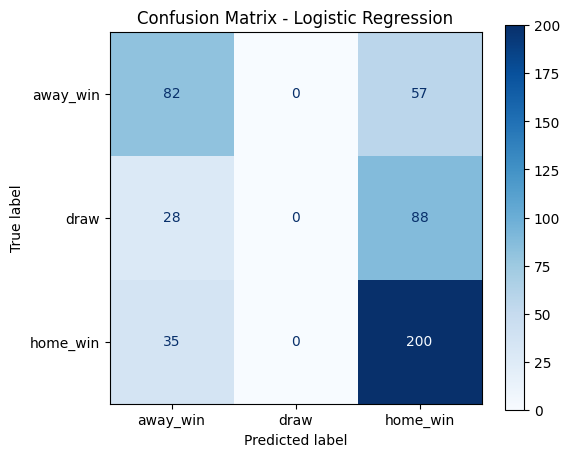

In [124]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# -------------------------
# 1. Data klaarzetten
# -------------------------

X = final_match_df.drop(columns=["result", "match_api_id"], errors="ignore")
y = final_match_df["result"]

# Numerieke en categorische kolommen herkennen
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

# OneHotEncoder compatibel maken met verschillende sklearn-versies
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

# -------------------------
# 2. Preprocessing
# -------------------------

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# -------------------------
# 3. Train/test split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# 4. Pipelines
# -------------------------

pipeline_logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    ))
])

pipeline_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

# -------------------------
# 5. Parameter grids
# -------------------------

param_grid_logreg = {
    "preprocessor__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"]
}

param_grid_knn = {
    "preprocessor__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

param_grid_rf = {
    "preprocessor__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

param_grid_gb = {
    "preprocessor__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

models = {
    "Logistic Regression": (pipeline_logreg, param_grid_logreg),
    "KNN": (pipeline_knn, param_grid_knn),
    "Random Forest": (pipeline_rf, param_grid_rf),
    "Gradient Boosting": (pipeline_gb, param_grid_gb)
}

# -------------------------
# 6. GridSearchCV per model
# -------------------------

results = []
best_models = {}

for name, (pipe, param_grid) in models.items():
    print(f"Training: {name}")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    results.append({
        "model": name,
        "best_cv_score": grid.best_score_,
        "best_params": grid.best_params_
    })

# Resultaten tonen
results_df = pd.DataFrame(results).sort_values(
    by="best_cv_score",
    ascending=False
)

display(results_df)

# -------------------------
# 7. Beste model kiezen
# -------------------------

best_model_name = results_df.iloc[0]["model"]
best_model = best_models[best_model_name]

print("Beste model:", best_model_name)
print("Beste parameters:", results_df.iloc[0]["best_params"])

# -------------------------
# 8. Test set evaluatie
# -------------------------

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# -------------------------
# 9. Confusion matrix
# -------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

Training: Logistic Regression


c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Training: KNN
Training: Random Forest
Training: Gradient Boosting


,model,best_cv_score,best_params
0,Logistic Regression,0.559758,"{'model__C': 0.01, 'model__penalty': 'l2', 'pr..."
2,Random Forest,0.553115,"{'model__max_depth': 5, 'model__min_samples_le..."
3,Gradient Boosting,0.552094,"{'model__learning_rate': 0.05, 'model__max_dep..."
1,KNN,0.502021,"{'model__metric': 'euclidean', 'model__n_neigh..."


Beste model: Logistic Regression
Beste parameters: {'model__C': 0.01, 'model__penalty': 'l2', 'preprocessor__num__scaler': StandardScaler()}
Accuracy: 0.576

Classification report:
              precision    recall  f1-score   support

    away_win       0.57      0.59      0.58       139
        draw       0.00      0.00      0.00       116
    home_win       0.58      0.85      0.69       235

    accuracy                           0.58       490
   macro avg       0.38      0.48      0.42       490
weighted avg       0.44      0.58      0.49       490



c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adels\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

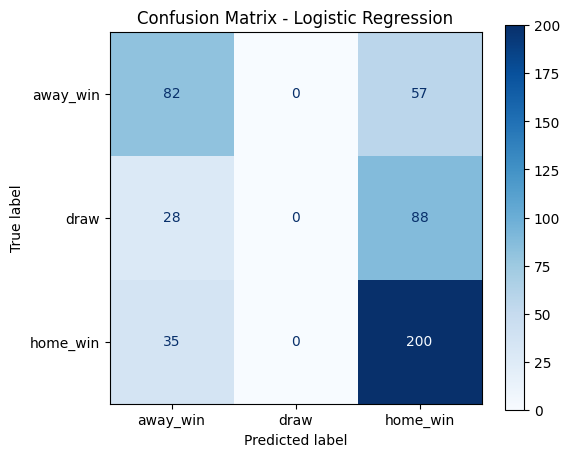

In [125]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# -------------------------
# 1. Data klaarzetten
# -------------------------

X = final_match_df.drop(columns=["result", "match_api_id"], errors="ignore")
y = final_match_df["result"]

# Numerieke en categorische kolommen herkennen
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

# OneHotEncoder compatibel maken met verschillende sklearn-versies
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

# -------------------------
# 2. Preprocessing
# -------------------------

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# -------------------------
# 3. Train/test split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# 4. Pipelines
# -------------------------

pipeline_logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    ))
])

pipeline_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

# -------------------------
# 5. Parameter grids
# -------------------------

param_grid_logreg = {
    "preprocessor__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"]
}

param_grid_knn = {
    "preprocessor__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

param_grid_rf = {
    "preprocessor__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

param_grid_gb = {
    "preprocessor__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

models = {
    "Logistic Regression": (pipeline_logreg, param_grid_logreg),
    "KNN": (pipeline_knn, param_grid_knn),
    "Random Forest": (pipeline_rf, param_grid_rf),
    "Gradient Boosting": (pipeline_gb, param_grid_gb)
}

# -------------------------
# 6. GridSearchCV per model
# -------------------------

results = []
best_models = {}

for name, (pipe, param_grid) in models.items():
    print(f"Training: {name}")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    results.append({
        "model": name,
        "best_cv_score": grid.best_score_,
        "best_params": grid.best_params_
    })

# Resultaten tonen
results_df = pd.DataFrame(results).sort_values(
    by="best_cv_score",
    ascending=False
)

display(results_df)

# -------------------------
# 7. Beste model kiezen
# -------------------------

best_model_name = results_df.iloc[0]["model"]
best_model = best_models[best_model_name]

print("Beste model:", best_model_name)
print("Beste parameters:", results_df.iloc[0]["best_params"])

# -------------------------
# 8. Test set evaluatie
# -------------------------

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# -------------------------
# 9. Confusion matrix
# -------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Confusion matrix Logistic Regression – Levi & Elyas

Om te beoordelen hoe goed ons model voetbalwedstrijden voorspelt, gebruiken we een **confusion matrix**.

Een confusion matrix is een tabel die de **voorspellingen van het model** vergelijkt met de **werkelijke uitslagen**.

Hierdoor kunnen we duidelijk zien:

- waar het model succesvol is
- waar het model fouten maakt
- welke uitslagen moeilijk te voorspellen zijn.

**Logistic Regression** heeft de hoogste accuracy van alle modellen, met een **accuracy van 0.57**.

Dit betekent dat het model **57% van de wedstrijden goed voorspelt**.

Uit de analyse blijkt dat het model vooral sterk is in het herkennen van de meest waarschijnlijke uitkomsten, zoals winst voor de favoriet.

Toch heeft het model een belangrijk probleem: het kan **gelijkspel bijna niet voorspellen**, zoals te zien is in de confusion matrix. Daarom is dit model niet per se beter dan **Random Forest**.

- `home_win` wordt het best voorspeld.
- `away_win` gaat redelijk.
- `draw` lukt dit model niet goed.

Wel zien we dat het aantal foute voorspellingen hoger wordt bij onvoorspelbare wedstrijden.  
Dit gebeurt bijvoorbeeld bij een onverwacht gelijkspel of wanneer een underdog verrassend wint.


## Opdracht 2 – AVG en persoonsgegevens (Thomas, Levi, Elyas)

### Beginselen (Thomas)

In deze dataset wordt gebruik gemaakt van persoonsgegevens van voetbalspelers. Daarom is het belangrijk om niet alleen technisch naar de data te kijken, maar ook juridisch en ethisch. Persoonsgegevens zijn alle gegevens die direct of indirect naar een persoon kunnen verwijzen. In deze dataset gaat het bijvoorbeeld om:

- namen  
- geboortedata  
- nationaliteit  
- lengte en gewicht  
- prestaties  
- posities op het veld  
- voorkeursvoet  
- het team  
- identifiers  

Omdat deze gegevens over echte en herkenbare spelers gaan, moet bij het gebruik van deze dataset rekening worden gehouden met de AVG.

De AVG heeft zes belangrijke beginselen:

- rechtmatigheid, behoorlijkheid en transparantie  
- doelbinding  
- dataminimalisatie  
- juistheid  
- opslagbeperking  
- vertrouwelijkheid en integriteit  

Daarnaast moet er voor het verwerken van persoonsgegevens een geldige grondslag zijn. De AVG noemt zes mogelijke grondslagen:

1. toestemming van de persoon  
2. uitvoering van een overeenkomst  
3. een wettelijke verplichting  
4. bescherming van vitale belangen  
5. taak van algemeen belang of openbaar gezag  
6. gerechtvaardigd belang  

---

### Rechtmatigheid, behoorlijkheid en transparantie (Thomas)

Rechtmatigheid betekent dat persoonsgegevens alleen gebruikt mogen worden als daar een geldige reden voor is. Behoorlijkheid betekent dat er eerlijk en zorgvuldig met de data moet worden omgegaan. Transparantie betekent dat duidelijk moet zijn welke data worden gebruikt, waarom deze data worden gebruikt en hoe dit gebeurt.

In deze sprint wordt gewerkt met een bestaande dataset uit Kaggle. De data worden gebruikt voor onderwijs en analyse. Het doel is dus niet commercieel, maar leergericht. Daardoor kan dit worden gezien als een vorm van gerechtvaardigd belang. Toch is het belangrijk om voorzichtig te blijven. Het feit dat de data openbaar beschikbaar zijn, betekent niet automatisch dat alles zonder regels gebruikt mag worden. Daarom is het belangrijk om duidelijk uit te leggen welke data worden gebruikt en voor welk doel.

In deze opdracht is ook sprake van behoorlijkheid en transparantie, omdat de analyse stap voor stap wordt uitgelegd. Er wordt niet geprobeerd om spelers te misleiden of om verborgen conclusies over hen te trekken. De verwerking van de data is juist open, omdat in de code en in de toelichting zichtbaar is hoe de data worden opgehaald, gekoppeld en geanalyseerd.

---

### Doelbinding (Thomas)

Doelbinding betekent dat persoonsgegevens alleen gebruikt mogen worden voor een vooraf bepaald en duidelijk doel. Data mogen dus niet zomaar voor een heel ander doel opnieuw worden gebruikt.

In deze sprint worden de gegevens van spelers gebruikt om analyses uit te voeren binnen een onderwijsopdracht. Het doel is om te leren werken met SQL, Python en data-analyse. De persoonsgegevens worden dus niet gebruikt voor reclame, verkoop of andere commerciële activiteiten. Het gebruik blijft binnen het doel van de opdracht. Daarmee wordt aan het beginsel van doelbinding voldaan.

Dit is belangrijk, omdat het laat zien dat de data niet willekeurig worden gebruikt. Er is vooraf een duidelijk doel: het onderzoeken van voetbaldata en het leren uitvoeren van analyses op een verantwoorde manier.

---

### Dataminimalisatie (Levi)

Dataminimalisatie betekent dat alleen de gegevens gebruikt mogen worden die echt nodig zijn voor het doel van het onderzoek. Je mag dus niet meer persoonsgegevens gebruiken dan nodig is.

In deze sprint wordt gewerkt met een bestaande dataset. Daardoor staan er ook gegevens in die niet voor elke deelopdracht nodig zijn. Dat kunnen we niet helemaal voorkomen, omdat de dataset al bestaat. Wat we wel kunnen doen, is bewust kiezen welke kolommen we gebruiken in de analyse.

Bijvoorbeeld: als we alleen de gemiddelde `overall_rating` per wedstrijd willen berekenen, dan hebben we niet alle spelergegevens nodig. In dat geval gebruiken we alleen de kolommen die nodig zijn om spelers te koppelen aan hun rating. Andere gegevens, zoals lengte, gewicht of nationaliteit, zijn dan niet nodig en worden niet meegenomen in die analyse.

Zo proberen we het gebruik van persoonsgegevens zo beperkt mogelijk te houden. Dit past goed bij het beginsel van dataminimalisatie.

---

### Juistheid (Levi)

Juistheid betekent dat persoonsgegevens correct moeten zijn en, als dat nodig is, ook actueel moeten blijven. Foute of verouderde gegevens kunnen leiden tot verkeerde conclusies.

In dit onderzoek wordt gebruik gemaakt van een bestaande dataset met voetbalgegevens uit de periode 2008 tot 2016. De data zijn afkomstig uit een openbare bron en bevatten datums, teaminformatie en spelergegevens. Daardoor is het mogelijk om te zien op welke periode de informatie betrekking heeft.

Toch is het belangrijk om eerlijk te zijn: we kunnen niet zelf volledig controleren of alle gegevens in de dataset altijd helemaal juist of volledig zijn. We gaan er wel van uit dat de bron bruikbaar is voor onderwijs en analyse. Daarom wordt de data gebruikt als werkmateriaal, maar met het besef dat absolute juistheid nooit volledig gegarandeerd kan worden.

Voor deze opdracht is dat acceptabel, omdat het doel vooral is om methoden van data-analyse te leren toepassen. Tegelijk blijft het belangrijk om voorzichtig te zijn met stellige conclusies.

---

### Opslagbeperking (Elyas)

Opslagbeperking betekent dat persoonsgegevens niet langer bewaard mogen worden dan nodig is voor het doel waarvoor zij worden gebruikt.

In deze sprint wordt gewerkt met een dataset die al online beschikbaar is via Kaggle. Wij hebben geen controle over hoe lang die originele bron online blijft staan. Maar we zijn wel verantwoordelijk voor de bestanden die wij zelf downloaden en lokaal opslaan tijdens het onderzoek.

Dat betekent dat de dataset, tussenbestanden, exports en analyses niet onnodig lang bewaard mogen blijven. Zodra de opdracht is afgerond en de bestanden niet meer nodig zijn, moeten ze worden verwijderd. Zo wordt voorkomen dat persoonsgegevens langer worden opgeslagen dan noodzakelijk is.

Dit is een belangrijk onderdeel van zorgvuldig werken met data. Ook bij een onderwijsopdracht moet worden nagedacht over hoe lang bestanden echt nodig zijn.

---

### Vertrouwelijkheid en integriteit (Elyas)

Vertrouwelijkheid en integriteit betekenen dat persoonsgegevens goed beschermd moeten worden tegen verlies, misbruik, ongewenste wijziging of toegang door onbevoegde personen.

Hoewel deze dataset openbaar beschikbaar is, blijft zorgvuldige omgang met de gegevens belangrijk. Bestanden die lokaal worden opgeslagen, moeten veilig worden bewaard. Dat kan bijvoorbeeld door ze alleen op een beveiligde computer of in een afgeschermde opslaglocatie op te slaan. Ook is het belangrijk dat niet iedereen zomaar toegang heeft tot deze bestanden.

Integriteit betekent dat de gegevens niet zomaar mogen worden aangepast of beschadigd. Als data onbedoeld veranderen, kan dat leiden tot verkeerde analyses en onbetrouwbare resultaten. Daarom is het belangrijk om netjes te werken, originele bestanden niet zomaar te overschrijven en duidelijk bij te houden welke bewerkingen zijn uitgevoerd.

Op deze manier blijft niet alleen de privacy beter beschermd, maar ook de kwaliteit van het onderzoek.

---

### Conclusie

In deze sprint worden persoonsgegevens gebruikt, waardoor de AVG een belangrijke rol speelt. De dataset bevat gegevens van identificeerbare spelers, dus het is nodig om bewust en zorgvuldig met deze data om te gaan.

Binnen de opdracht wordt geprobeerd om de AVG-beginselen zo goed mogelijk toe te passen. Er is een duidelijk doel, er worden alleen relevante gegevens gebruikt, en de werkwijze wordt transparant uitgelegd. Ook wordt rekening gehouden met opslag en beveiliging van bestanden.

Daarmee laat deze opdracht zien dat data-analyse niet alleen om techniek gaat, maar ook om verantwoordelijkheid. Een goede analist kijkt dus niet alleen naar code en resultaten, maar denkt ook na over privacy, zorgvuldigheid en het juiste gebruik van persoonsgegevens.

Bronnen: 1. [LINK](https://www.autoriteitpersoonsgegevens.nl/themas/basis-avg/avg-algemeen/de-avg-in-het-kort) 
         2. [LINK](https://gdpr-info.eu/art-5-gdpr/) 


## AI-act: Welke categorie (Roan)
 
Wij moeten een systeem maken die op basis van gegevens in een match kan voorspellen welke team wint of welke teams gelijkspel spelen. Het doel van dit systeem is om miskopen te voorkomen.

Dit systeem kan afhankelijk van het doel verschillen van categorie:

- Als het systeem de technisch directeur alleen helpt nieuwe spelers in te kopen en oude spelers te verkopen, dan zal dit systeem onder hoog risico vallen. Volgens de richtlijnen van de Europses Comissie vallen systemen die een grote impact kunnen hebben op veiligheid, gezondheid en fundamentele rechten in deze categorie. Dit systeem heeft namelijk hoge risico op de carriëre van een speler, wat een grote impact maakt op werkgelegenheid en werknemersbeheer.

- Als het systeem ook de functie krijgt om informatie door te verkopen aan goksites, dan zal dit systeem vallen onder hoog risico AI. Volgens de richtlijnen van de Europses Comissie vallen systemen die een grote impact kunnen hebben op veiligheid, gezondheid en fundamentele rechten in deze categorie. Dit systeem zou namelijk zware gevolgen kunnen hebben op de financiële gezondheid van een persoon. Als dit systeem gebruikt wordt om gokverslavingen te voeden, dan zal dit vallen onder verboden/ onaanvaardbaar risico AI, omdat dit systeem kwetsbare groepen zal exploiteren.


Bron: AI-verordening. (11 mei 2026). De Digitale Toekomst van Europa Vormgeven. [LINK](https://digital-strategy.ec.europa.eu/nl/policies/regulatory-framework-ai)

# Sprint (6)